# AFD-CNN Fall Detection on Actigraph Tagged Signals — SisFall Model (4-limb mean)

Identical to `AFD-CNN on Actigraph tagged signals - SisFall model.ipynb` but feeds the
**four-limb mean** (RW+LW+RA+LA averaged per axis) into the **SisFall-trained model** (`model/sisfall_model.ckpt`) with its matching normalization.

Pipeline overview:
1. Load raw 64 Hz Actigraph data for four limbs (RW, LW, RA, LA)
2. Compute the four-limb mean as a lumbar proxy
3. Use the tagged windows (`classification_windows_2026_03_29`) to restrict analysis
4. Run **SKDH** `PredictGaitLumbarLgbm` within each tagged window to detect walking bouts
5. Scan **all tagged timestamps** using the **four-limb mean x/y/z** as AFD-CNN input
   (200 samples @ 100 Hz = 2 s, step = 25 samples = 0.25 s)
6. Visualise predictions per task and summarise fall-alert rates

**Rationale:** averaging across all four limbs damps limb-specific arm-swing dynamics and
produces a signal closer to a lumbar/waist placement, which is how SisFall was recorded.

**Key difference from the original notebook — normalization:**

| Notebook | Model | Training data | g → [0, 255] formula |
|---|---|---|---|
| Original | `model/model.ckpt` | MobiAct (phone, m/s²) | `(g × 9.81 + 20) × 6` |
| **This notebook** | **`model/sisfall_model.ckpt`** | **SisFall (ADXL345 ADC)** | **`(g × 256 + 4096) / 8192 × 255`** |

The SisFall formula converts g units to equivalent ADXL345 13-bit ADC counts
(±16 g, 256 counts/g) and then applies the same linear normalization used during training.
Maps: g = 0 → 127.5, g = ±16 → 255 / 0.

**Input image layout (repeat-acc, both halves identical):**

| Image rows | Content |
|---|---|
| 0–9 (top half) | ADXL345-equivalent accelerometer (ax/ay/az) |
| 10–19 (bottom half) | Repeated copy of top half |

Source data: `/home/ubuntu/git/gait_analysis/Walkin Actigraphs tests/`  
AFD-CNN model: `/home/ubuntu/git/FD-CNN/model/sisfall_model.ckpt`

## 0. Setup: imports

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import gcd
from scipy.signal import resample_poly

# scikit-digital-health (pre-installed in the fd-cnn venv)
import skdh
from skdh.context import PredictGaitLumbarLgbm

print('skdh version:', skdh.__version__)
print('numpy version:', np.__version__)

skdh version: 0.17.9
numpy version: 2.4.4


## 1. Load Actigraph data — 2026-03-29 session

In [2]:
BASE_DIR = Path('/home/ubuntu/git/gait_analysis/Walkin Actigraphs tests')

def load_acti_data(base_dir, fname):
    """
    Load a raw Actigraph CSV file and return a clean DataFrame.

    - Skips '#'-prefixed metadata header lines.
    - Computes vector magnitude (acc_magnitude) from all accelerometer axes.
    - Aliases axes as 'x', 'y', 'z'.
    - Parses 'Timestamp UTC' to timezone-aware datetime.
    - Builds 'seconds_elapsed' from t0=0; adds sub-second correction at 64 Hz.
    """
    df = pd.read_csv(base_dir / fname, comment='#', skip_blank_lines=True)
    df.columns = [c.strip() for c in df.columns]

    df['acc_magnitude'] = np.sqrt((df.iloc[:, 2:] ** 2).sum(axis=1))
    df['x'] = df['Accelerometer X']
    df['y'] = df['Accelerometer Y']
    df['z'] = df['Accelerometer Z']

    df['Timestamp UTC'] = pd.to_datetime(df['Timestamp UTC'], utc=True, errors='coerce')

    t0 = df['Timestamp UTC'].dropna().iloc[0]
    df['seconds_elapsed'] = (df['Timestamp UTC'] - t0).dt.total_seconds().astype(float)

    # Sub-second correction: file timestamps are per-second; reconstruct intra-second
    # position from sample index modulo 64 (sampling rate = 64 Hz).
    sec_correction = np.arange(len(df)) % 64 / 64.0
    df['seconds_elapsed'] += sec_correction
    df['Timestamp UTC'] += pd.to_timedelta(sec_correction, unit='s')

    return df


# Load all four limbs for the 2026-03-29 session
df_RW = load_acti_data(BASE_DIR, 'EALS-DATA-004_STM2D48232042_2026-03-29_12_00_00_AM_1.CSV')
df_LW = load_acti_data(BASE_DIR, 'EALS-DATA-002_STM2D48230423_2026-03-29_12_00_00_AM_1.CSV')
df_RA = load_acti_data(BASE_DIR, 'EALS-DATA-001_STM2D48230106_2026-03-29_12_00_00_AM_1.CSV')
df_LA = load_acti_data(BASE_DIR, 'ESLD-DATA-003_STM2D48232727_2026-03-29_12_00_00_AM_1.CSV')

for lbl, df in [('RW', df_RW), ('LW', df_LW), ('RA', df_RA), ('LA', df_LA)]:
    print(f'{lbl}: {len(df):,} samples | '
          f'{df["Timestamp UTC"].iloc[0]} \u2192 {df["Timestamp UTC"].iloc[-1]}')

RW: 10,944,960 samples | 2026-03-29 00:00:00+00:00 → 2026-03-31 00:46:22.984375+00:00
LW: 11,153,856 samples | 2026-03-29 00:00:00+00:00 → 2026-03-31 00:24:38.984375+00:00
RA: 11,055,808 samples | 2026-03-29 00:00:00+00:00 → 2026-03-30 23:59:06.984375+00:00
LA: 10,631,296 samples | 2026-03-29 00:00:00+00:00 → 2026-03-30 22:08:33.984375+00:00


## 2. Tagged classification windows

In [3]:
# Manually tagged activity windows from the source notebook
# (Walking detection libraries & Actigraphs signal.ipynb, 2026-03-29 session)
classification_windows_2026_03_29 = [
    ['2026-03-30 20:09:00', '2026-03-30 20:12:00'],  # Put on
    ['2026-03-30 20:13:40', '2026-03-30 20:14:40'],  # RW
    ['2026-03-30 20:14:45', '2026-03-30 20:15:45'],  # LW
    ['2026-03-30 20:15:50', '2026-03-30 20:16:50'],  # RA
    ['2026-03-30 20:17:00', '2026-03-30 20:18:00'],  # LA
    ['2026-03-30 20:18:00', '2026-03-30 20:26:00'],  # In house movement
    ['2026-03-30 20:26:00', '2026-03-30 20:49:00'],  # Biking
    ['2026-03-30 20:49:00', '2026-03-30 20:59:00'],  # In house movement
    ['2026-03-30 21:00:00', '2026-03-30 21:01:30'],  # Walking fast in gym
    ['2026-03-30 21:01:50', '2026-03-30 21:03:50'],  # Running in gym
    ['2026-03-30 21:04:00', '2026-03-30 21:05:30'],  # Elliptic in gym
    ['2026-03-30 21:05:00', '2026-03-30 21:14:00'],  # In house movement
    ['2026-03-30 21:14:00', '2026-03-30 21:38:00'],  # Biking
    ['2026-03-30 21:38:00', '2026-03-30 21:43:00'],  # In house movement
    ['2026-03-30 21:43:40', '2026-03-30 21:44:20'],  # TT
    ['2026-03-30 21:45:00', '2026-03-30 21:47:00'],  # In house movement
    ['2026-03-30 21:47:00', '2026-03-30 22:03:00'],  # PC
    ['2026-03-30 22:03:00', '2026-03-30 22:07:00'],  # In house movement
    ['2026-03-30 22:07:00', '2026-03-30 22:10:00'],  # Put off
]

classification_tasks_2026_03_29 = [
    'Put on',
    'RW',
    'LW',
    'RA',
    'LA',
    'In house movement',
    'Biking',
    'In house movement',
    'Walking fast in gym',
    'Running in gym',
    'Elliptic in gym',
    'In house movement',
    'Biking',
    'In house movement',
    'TT',
    'In house movement',
    'PC',
    'In house movement',
    'Put off',
]

# Build tidy interval DataFrame
task_intervals = pd.DataFrame({
    'start_time': [pd.Timestamp(w[0], tz='UTC') for w in classification_windows_2026_03_29],
    'end_time':   [pd.Timestamp(w[1], tz='UTC') for w in classification_windows_2026_03_29],
    'task':       classification_tasks_2026_03_29,
})

SESSION_START = task_intervals['start_time'].min()
SESSION_END   = task_intervals['end_time'].max()

print(f'Session span: {SESSION_START} \u2192 {SESSION_END}')
print(f'Total tagged windows: {len(task_intervals)}')
print(task_intervals[['task', 'start_time', 'end_time']].to_string(index=False))

Session span: 2026-03-30 20:09:00+00:00 → 2026-03-30 22:10:00+00:00
Total tagged windows: 19
               task                start_time                  end_time
             Put on 2026-03-30 20:09:00+00:00 2026-03-30 20:12:00+00:00
                 RW 2026-03-30 20:13:40+00:00 2026-03-30 20:14:40+00:00
                 LW 2026-03-30 20:14:45+00:00 2026-03-30 20:15:45+00:00
                 RA 2026-03-30 20:15:50+00:00 2026-03-30 20:16:50+00:00
                 LA 2026-03-30 20:17:00+00:00 2026-03-30 20:18:00+00:00
  In house movement 2026-03-30 20:18:00+00:00 2026-03-30 20:26:00+00:00
             Biking 2026-03-30 20:26:00+00:00 2026-03-30 20:49:00+00:00
  In house movement 2026-03-30 20:49:00+00:00 2026-03-30 20:59:00+00:00
Walking fast in gym 2026-03-30 21:00:00+00:00 2026-03-30 21:01:30+00:00
     Running in gym 2026-03-30 21:01:50+00:00 2026-03-30 21:03:50+00:00
    Elliptic in gym 2026-03-30 21:04:00+00:00 2026-03-30 21:05:30+00:00
  In house movement 2026-03-30 21:05:00+00:

## 3. Four-limb mean (lumbar proxy)

In [4]:
# Average X, Y, Z and acc_magnitude across all four limbs on the shared timestamp grid.
_dfs = {'RW': df_RW, 'LW': df_LW, 'RA': df_RA, 'LA': df_LA}
df_mean = df_RW[['Timestamp UTC']].copy()
for lbl, df in _dfs.items():
    df_mean = df_mean.merge(
        df[['Timestamp UTC', 'acc_magnitude', 'x', 'y', 'z']].rename(columns={
            'acc_magnitude': f'acc_magnitude_{lbl}',
            'x': f'x_{lbl}', 'y': f'y_{lbl}', 'z': f'z_{lbl}',
        }),
        on='Timestamp UTC',
        how='inner',
    )

for col in ['acc_magnitude', 'x', 'y', 'z']:
    df_mean[col] = df_mean[[f'{col}_{lbl}' for lbl in _dfs]].mean(axis=1)

print(f'Four-limb mean: {len(df_mean):,} shared samples')
print(f'Time range: {df_mean["Timestamp UTC"].iloc[0]} \u2192 {df_mean["Timestamp UTC"].iloc[-1]}')

Four-limb mean: 10,338,944 shared samples
Time range: 2026-03-29 00:00:00+00:00 → 2026-03-30 22:08:33.984375+00:00


## 4. Overview plot — acc_magnitude with task backgrounds

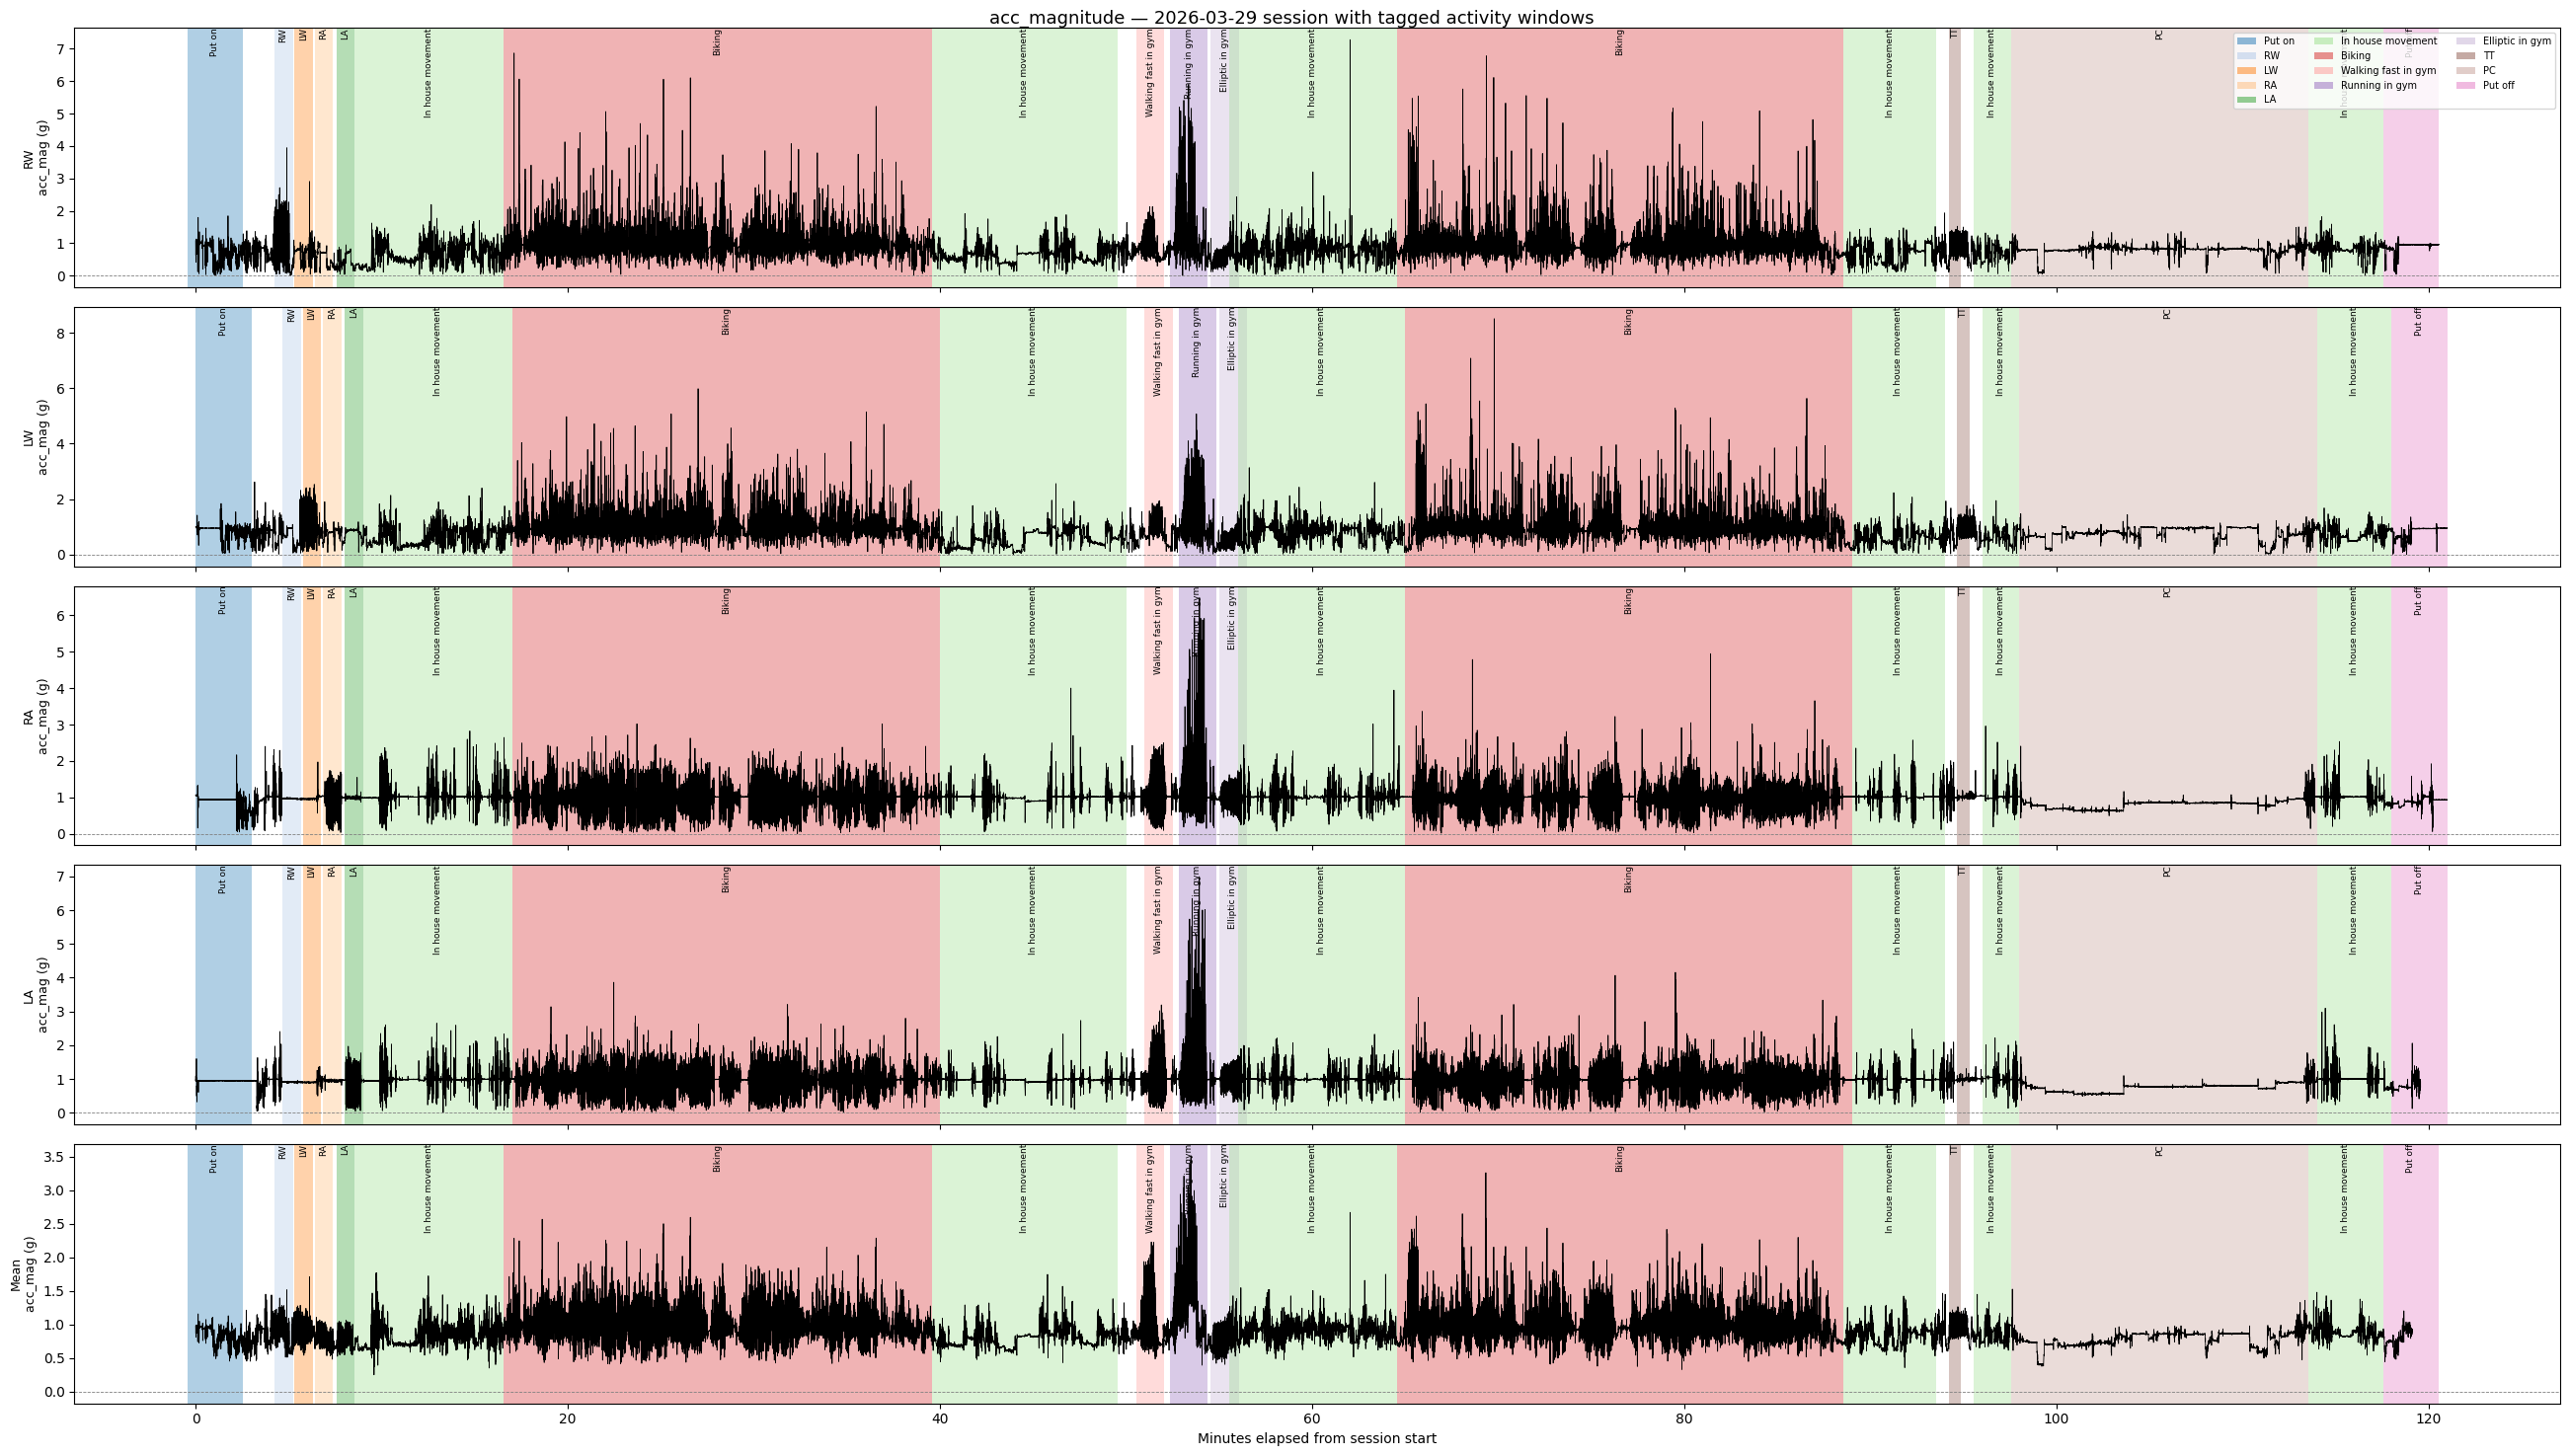

In [5]:
_unique_tasks = list(dict.fromkeys(classification_tasks_2026_03_29))
_palette = list(plt.cm.tab20.colors)
TASK_COLORS = {t: _palette[i % len(_palette)] for i, t in enumerate(_unique_tasks)}

def plot_session_overview(signals_dict, task_intervals, session_start, session_end, title=''):
    """Plot acc_magnitude for each signal with task-coloured background bands."""
    fig, axes = plt.subplots(len(signals_dict), 1,
                              figsize=(26, 3 * len(signals_dict)), sharex=True)
    if len(signals_dict) == 1:
        axes = [axes]

    for ax, (label, df) in zip(axes, signals_dict.items()):
        plot_df = df[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
        plot_df = plot_df[
            (plot_df['Timestamp UTC'] >= session_start) &
            (plot_df['Timestamp UTC'] <= session_end)
        ].copy()
        if plot_df.empty:
            ax.set_title(f'{label} \u2014 no data')
            continue

        t_ref = plot_df['Timestamp UTC'].iloc[0]
        plot_df['min_elapsed'] = (plot_df['Timestamp UTC'] - t_ref).dt.total_seconds() / 60.0

        for _, row in task_intervals.iterrows():
            s = (row['start_time'] - t_ref).total_seconds() / 60.0
            e = (row['end_time']   - t_ref).total_seconds() / 60.0
            ax.axvspan(s, e, color=TASK_COLORS.get(row['task'], '#cccccc'), alpha=0.35, linewidth=0)
            ax.text((s + e) / 2, 1.0, row['task'],
                    transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=6.5, rotation=90, clip_on=True)

        if len(plot_df) > 50_000:
            stride = max(1, len(plot_df) // 50_000)
            plot_df = plot_df.iloc[::stride].copy()

        ax.plot(plot_df['min_elapsed'], plot_df['acc_magnitude'], color='black', lw=0.6)
        ax.axhline(0, color='0.5', ls='--', lw=0.6)
        ax.set_ylabel(f'{label}\nacc_mag (g)', fontsize=9)

    legend_handles = [
        mpatches.Patch(facecolor=TASK_COLORS[t], edgecolor='none', alpha=0.5, label=t)
        for t in _unique_tasks
    ]
    axes[0].legend(handles=legend_handles, loc='upper right', fontsize=7, ncol=3)
    axes[-1].set_xlabel('Minutes elapsed from session start')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


all_signals = {'RW': df_RW, 'LW': df_LW, 'RA': df_RA, 'LA': df_LA, 'Mean': df_mean}
plot_session_overview(
    all_signals, task_intervals, SESSION_START, SESSION_END,
    title='acc_magnitude \u2014 2026-03-29 session with tagged activity windows',
)

## 5. SKDH gait detection on the full tagged session

In [6]:
FS_ACTI = 64  # Actigraph sampling rate (Hz)


def resolve_time_window(time_window):
    """Convert [t0, tf] strings or Timestamps to UTC-aware pd.Timestamps."""
    if time_window is None:
        return None, None
    t0 = time_window[0] if isinstance(time_window[0], pd.Timestamp) else pd.Timestamp(time_window[0], tz='UTC')
    tf = time_window[1] if isinstance(time_window[1], pd.Timestamp) else pd.Timestamp(time_window[1], tz='UTC')
    return t0, tf


def run_skdh_on_window(df_signal, t0, tf, fs=FS_ACTI):
    """
    Run PredictGaitLumbarLgbm on a time slice of df_signal.

    Returns
    -------
    plot_df : filtered DataFrame slice used for plotting
    result  : raw dict with 'Gait Bout Start' / 'Gait Bout Stop' (Unix seconds)
    """
    plot_df = df_signal[['Timestamp UTC', 'x', 'y', 'z']].dropna().copy()
    plot_df = plot_df[
        (plot_df['Timestamp UTC'] >= t0) & (plot_df['Timestamp UTC'] <= tf)
    ].copy()
    if plot_df.empty:
        return plot_df, {'Gait Bout Start': np.array([]), 'Gait Bout Stop': np.array([])}

    time_s = plot_df['Timestamp UTC'].astype('int64').to_numpy() / 1e9
    accel  = plot_df[['x', 'y', 'z']].to_numpy(dtype=float)
    result = PredictGaitLumbarLgbm().predict(time=time_s, accel=accel, fs=fs)
    return plot_df, result


def skdh_result_to_intervals(plot_df, result):
    """Convert SKDH bout boundaries to a tidy interval DataFrame (prediction 0/1)."""
    plot_start = plot_df['Timestamp UTC'].iloc[0]
    plot_end   = plot_df['Timestamp UTC'].iloc[-1]

    gait_starts = pd.to_datetime(result['Gait Bout Start'], unit='s', utc=True)
    gait_stops  = pd.to_datetime(result['Gait Bout Stop'],  unit='s', utc=True)

    intervals, current = [], plot_start
    for bout_start, bout_stop in zip(gait_starts, gait_stops):
        bout_start = max(bout_start, plot_start)
        bout_stop  = min(bout_stop,  plot_end)
        if bout_start > current:
            intervals.append({'start_time': current,     'end_time': bout_start, 'prediction': 0})
        if bout_stop > bout_start:
            intervals.append({'start_time': bout_start,  'end_time': bout_stop,  'prediction': 1})
        current = max(current, bout_stop)
    if current < plot_end:
        intervals.append({'start_time': current, 'end_time': plot_end, 'prediction': 0})
    if not intervals:
        intervals.append({'start_time': plot_start, 'end_time': plot_end, 'prediction': 0})

    return pd.DataFrame(intervals)


# Run SKDH over the entire tagged session (using the four-limb mean as lumbar proxy)
print('Running SKDH PredictGaitLumbarLgbm over the full tagged session \u2026')
plot_df_skdh, skdh_result_session = run_skdh_on_window(
    df_mean, SESSION_START, SESSION_END
)
skdh_intervals_session = skdh_result_to_intervals(plot_df_skdh, skdh_result_session)

n_bouts = len(skdh_result_session.get('Gait Bout Start', []))
print(f'SKDH detected {n_bouts} gait bout(s) over the full session')
if n_bouts:
    for i, (s, e) in enumerate(zip(
        pd.to_datetime(skdh_result_session['Gait Bout Start'], unit='s', utc=True),
        pd.to_datetime(skdh_result_session['Gait Bout Stop'],  unit='s', utc=True),
    )):
        dur = (e - s).total_seconds()
        print(f'  Bout {i+1}: {s} \u2192 {e}  ({dur:.0f} s)')

Running SKDH PredictGaitLumbarLgbm over the full tagged session …
SKDH detected 52 gait bout(s) over the full session
  Bout 1: 2026-03-30 20:13:27+00:00 → 2026-03-30 20:13:30+00:00  (3 s)
  Bout 2: 2026-03-30 20:18:57+00:00 → 2026-03-30 20:19:03+00:00  (6 s)
  Bout 3: 2026-03-30 20:21:42+00:00 → 2026-03-30 20:21:45+00:00  (3 s)
  Bout 4: 2026-03-30 20:22:03+00:00 → 2026-03-30 20:22:09+00:00  (6 s)
  Bout 5: 2026-03-30 20:22:24+00:00 → 2026-03-30 20:22:27+00:00  (3 s)
  Bout 6: 2026-03-30 20:22:51+00:00 → 2026-03-30 20:22:54+00:00  (3 s)
  Bout 7: 2026-03-30 20:26:00+00:00 → 2026-03-30 20:26:03+00:00  (3 s)
  Bout 8: 2026-03-30 20:34:15+00:00 → 2026-03-30 20:34:18+00:00  (3 s)
  Bout 9: 2026-03-30 20:35:30+00:00 → 2026-03-30 20:35:33+00:00  (3 s)
  Bout 10: 2026-03-30 20:36:54+00:00 → 2026-03-30 20:36:57+00:00  (3 s)
  Bout 11: 2026-03-30 20:38:00+00:00 → 2026-03-30 20:38:06+00:00  (6 s)
  Bout 12: 2026-03-30 20:38:18+00:00 → 2026-03-30 20:38:21+00:00  (3 s)
  Bout 13: 2026-03-30 20:38

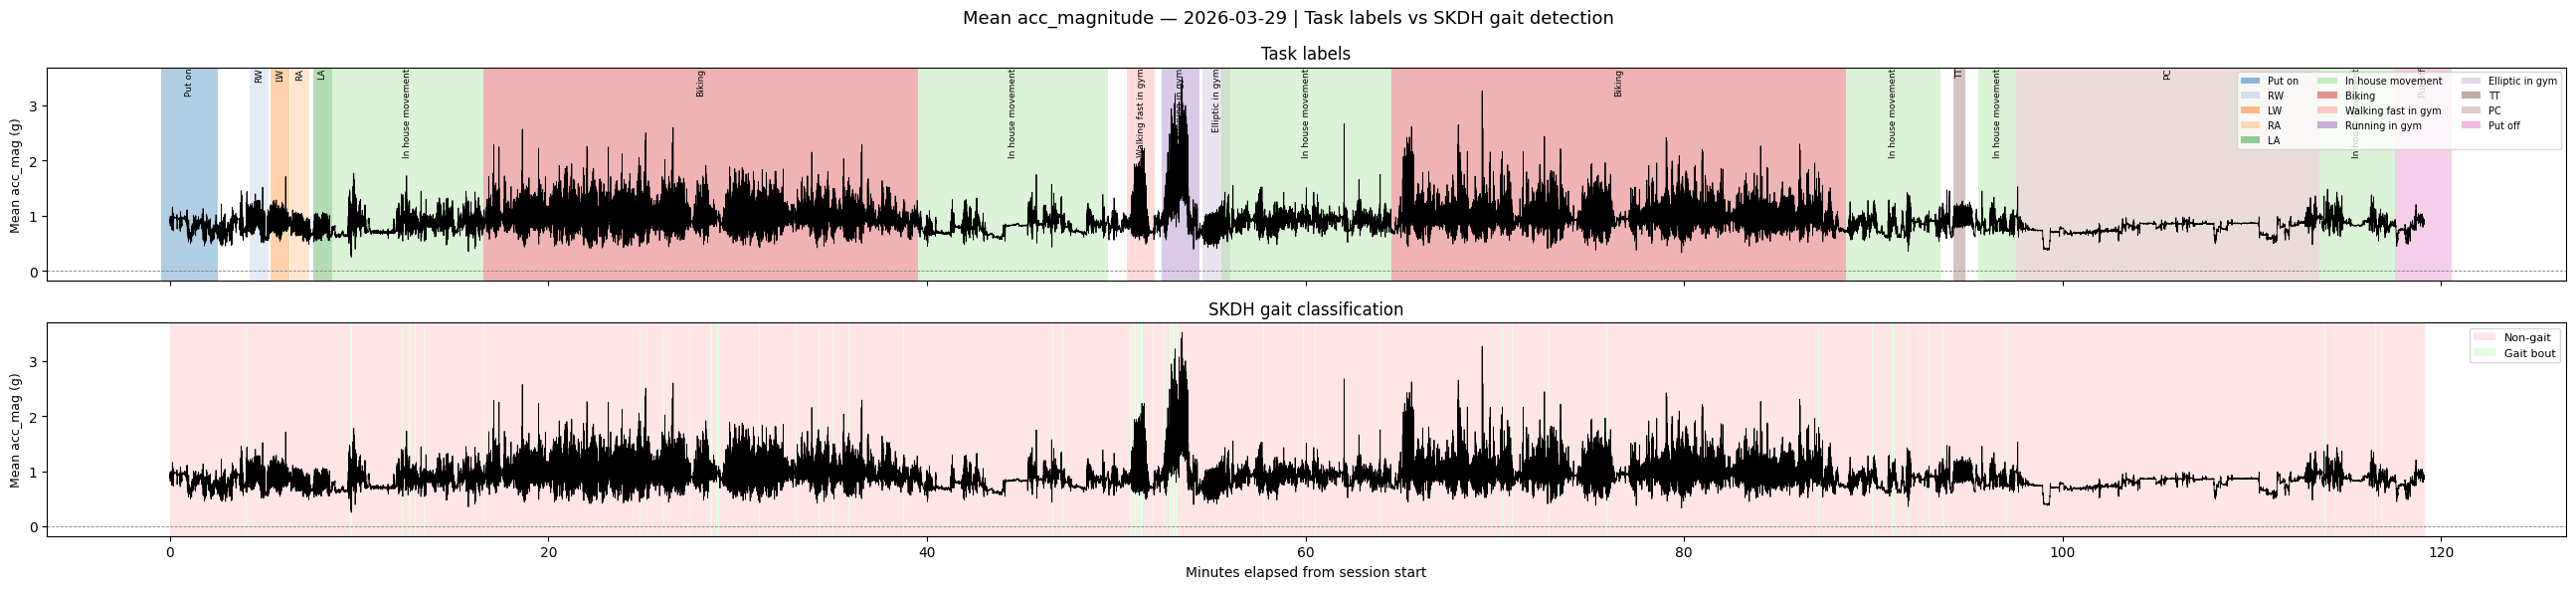

In [7]:
_COLORS_SKDH = {0: '#ffcccc', 1: '#ccffcc'}

def _min_elapsed(ts_series, t_ref):
    return (ts_series - t_ref).dt.total_seconds() / 60.0


plot_df_mean = df_mean[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
plot_df_mean = plot_df_mean[
    (plot_df_mean['Timestamp UTC'] >= SESSION_START) &
    (plot_df_mean['Timestamp UTC'] <= SESSION_END)
].copy()
t_ref = plot_df_mean['Timestamp UTC'].iloc[0]
plot_df_mean['min_elapsed'] = _min_elapsed(plot_df_mean['Timestamp UTC'], t_ref)

if len(plot_df_mean) > 50_000:
    _stride = max(1, len(plot_df_mean) // 50_000)
    plot_df_mean_ds = plot_df_mean.iloc[::_stride].copy()
else:
    plot_df_mean_ds = plot_df_mean

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(26, 6), sharex=True)

# \u2500\u2500 Top panel: task labels \u2500\u2500
for _, row in task_intervals.iterrows():
    s = (row['start_time'] - t_ref).total_seconds() / 60.0
    e = (row['end_time']   - t_ref).total_seconds() / 60.0
    ax1.axvspan(s, e, color=TASK_COLORS.get(row['task'], '#cccccc'), alpha=0.35, linewidth=0)
    ax1.text((s + e) / 2, 1.0, row['task'],
             transform=ax1.get_xaxis_transform(),
             ha='center', va='top', fontsize=6.5, rotation=90, clip_on=True)
ax1.plot(plot_df_mean_ds['min_elapsed'], plot_df_mean_ds['acc_magnitude'], color='black', lw=0.6)
ax1.axhline(0, color='0.5', ls='--', lw=0.6)
ax1.set_ylabel('Mean acc_mag (g)', fontsize=9)
ax1.set_title('Task labels')
ax1.legend(
    handles=[mpatches.Patch(facecolor=TASK_COLORS[t], edgecolor='none', alpha=0.5, label=t)
             for t in _unique_tasks],
    loc='upper right', fontsize=7, ncol=3,
)

# \u2500\u2500 Bottom panel: SKDH detections \u2500\u2500
skdh_i = skdh_intervals_session.copy()
skdh_i['start_min'] = _min_elapsed(skdh_i['start_time'], t_ref)
skdh_i['end_min']   = _min_elapsed(skdh_i['end_time'],   t_ref)
for _, row in skdh_i.iterrows():
    ax2.axvspan(row['start_min'], row['end_min'],
                color=_COLORS_SKDH[row['prediction']], alpha=0.5, linewidth=0)
ax2.plot(plot_df_mean_ds['min_elapsed'], plot_df_mean_ds['acc_magnitude'], color='black', lw=0.6)
ax2.axhline(0, color='0.5', ls='--', lw=0.6)
ax2.set_ylabel('Mean acc_mag (g)', fontsize=9)
ax2.set_title('SKDH gait classification')
ax2.legend(
    handles=[
        mpatches.Patch(facecolor='#ffcccc', edgecolor='none', alpha=0.5, label='Non-gait'),
        mpatches.Patch(facecolor='#ccffcc', edgecolor='none', alpha=0.5, label='Gait bout'),
    ],
    loc='upper right', fontsize=8,
)
ax2.set_xlabel('Minutes elapsed from session start')

fig.suptitle('Mean acc_magnitude \u2014 2026-03-29 | Task labels vs SKDH gait detection', fontsize=13)
plt.tight_layout()
plt.show()

## 6. AFD-CNN setup — SisFall model

In [8]:
import importlib
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC   = '/home/ubuntu/git/FD-CNN/src'
FD_CNN_MODEL = '/home/ubuntu/git/FD-CNN/model/sisfall_model.ckpt'   # SisFall model

if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)

import cnn as cnn_module
importlib.reload(cnn_module)

FD_CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
FD_CLASS_NAMES = {
    0: 'Fall',
    2: 'Walk',
    3: 'Jog',
    4: 'Jump',
    5: 'Up-stairs',
    6: 'Down-stairs',
    7: 'Stand\u2192Sit',
    9: 'Sit\u2192Stand',
}
FD_COLORS = {
    0: '#e84040',  # Fall        \u2014 red
    2: '#4a8fd4',  # Walk        \u2014 blue
    3: '#56b56e',  # Jog         \u2014 green
    4: '#e09c30',  # Jump        \u2014 orange
    5: '#9b6bd4',  # Up-stairs   \u2014 purple
    6: '#d47bb5',  # Down-stairs \u2014 pink
    7: '#888888',  # Stand\u2192Sit  \u2014 grey
    9: '#aaaaaa',  # Sit\u2192Stand  \u2014 light grey
}

# Build TensorFlow 1 graph and restore SisFall checkpoint
tf.reset_default_graph()
fd_x_ph            = tf.placeholder(tf.float32, [None, 1200], name='fd_input')
fd_logits, fd_keep = cnn_module.fall_net(fd_x_ph)
fd_probs_op        = tf.nn.softmax(fd_logits)

fd_saver = tf.train.Saver()
fd_sess  = tf.Session()
fd_saver.restore(fd_sess, FD_CNN_MODEL)
print('AFD-CNN SisFall model restored from', FD_CNN_MODEL)
print('Logits shape:', fd_logits.shape)

I0000 00:00:1776375438.439878   19610 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
AFD-CNN SisFall model restored from /home/ubuntu/git/FD-CNN/model/sisfall_model.ckpt
Logits shape: (?, 8)


E0000 00:00:1776375439.846547   19610 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776375439.850659   19610 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 7. Sliding-window scanning over ALL tagged timestamps

We scan **every tagged time window** (not just SKDH walking bouts) with a 200-sample
sliding window at 100 Hz (= 2 s), step = 25 samples (= 0.25 s).

Actigraph data is at 64 Hz → each window is resampled to 100 Hz (AFD-CNN training rate)
before preprocessing.

**SisFall normalization:** Actigraph g-unit values are converted to equivalent ADXL345
13-bit ADC counts (±16 g, 256 counts/g) and then normalized to [0, 255]:  
`(g × 256 + 4096) / 8192 × 255`  
This matches exactly what was used when building `data/sisfall_train.csv` in `SisFall_train.ipynb`.

**Input image layout (repeat-acc):** both halves encode the accelerometer (top = bottom).

In [9]:
# \u2500\u2500 Resampling & preprocessing constants \u2500\u2500
FD_FS_IN     = FS_ACTI   # 64 Hz  \u2014 Actigraph native rate
FD_FS_TRAIN  = 100       # Hz     \u2014 AFD-CNN training rate
FD_WIN_LEN   = 200       # samples at 100 Hz = 2 s
FD_STEP      = 25        # samples at 100 Hz = 0.25 s


def resample_bout(arr_g, fs_in, fs_out):
    """Polyphase resample (N, 3) g-unit array from fs_in to fs_out."""
    g = gcd(int(fs_in), int(fs_out))
    return resample_poly(arr_g, int(fs_out) // g, int(fs_in) // g, axis=0).astype(np.float32)


def g_to_uint8(arr_g):
    """
    Convert Actigraph g-unit data to [0, 255] matching SisFall ADXL345 training normalization.

    SisFall ADXL345: 13-bit ADC, \u00b116 g \u2192 ADC range [-4096, 4095].
    Equivalent ADC = g \u00d7 256  (since 4096 counts = 16 g \u2192 256 counts/g).
    Normalization applied during training: (ADC + 4096) / 8192 \u00d7 255.
    Combined formula: (g \u00d7 256 + 4096) / 8192 \u00d7 255 = (g / 32 + 0.5) \u00d7 255.
    Maps: g = 0 \u2192 127.5, g = +16 \u2192 255, g = -16 \u2192 0.
    """
    adc_equiv = arr_g * 256.0
    return np.clip((adc_equiv + 4096.0) / 8192.0 * 255.0, 0.0, 255.0).astype(np.float32)


def extract_windows_from_segment(accel_64hz, timestamps_64hz, win_len, step, fs_in, fs_out):
    """
    Resample a (N, 3) segment from fs_in to fs_out, then scan with a sliding window.

    Each window: (win_len, 3) accelerometer \u2192 g_to_uint8 \u2192 flatten to (600,).
    The repeat-acc variant duplicates the acc half to produce the full (1200,) model input
    (top half = acc, bottom half = repeated copy), consistent with SisFall_train.ipynb.

    Returns
    -------
    windows : (N_windows, 1200) float32 in [0, 255]
    meta    : list of dicts with 'win_idx', 'start_dt', 'end_dt'
    """
    if len(accel_64hz) == 0:
        return np.empty((0, 1200), dtype=np.float32), []

    scale = fs_out / fs_in
    arr_resampled = resample_bout(accel_64hz, fs_in, fs_out)  # (N_resamp, 3)
    arr_uint8     = g_to_uint8(arr_resampled)                  # (N_resamp, 3) \u2014 SisFall normalization

    windows, meta = [], []
    n_resamp = len(arr_resampled)

    for w_idx, off in enumerate(range(0, n_resamp - win_len + 1, step)):
        chunk = arr_uint8[off: off + win_len]           # (200, 3) \u2014 accelerometer
        flat  = chunk.flatten()                          # (600,)   \u2014 acc flattened
        windows.append(np.concatenate([flat, flat]))    # (1200,)  \u2014 repeat-acc

        # Map resampled sample indices back to original 64 Hz timestamps
        s_orig = min(int(off / scale),             len(timestamps_64hz) - 1)
        e_orig = min(int((off + win_len) / scale),  len(timestamps_64hz) - 1)
        meta.append(dict(
            win_idx=w_idx,
            start_dt=timestamps_64hz[s_orig],
            end_dt=timestamps_64hz[e_orig],
        ))

    return np.array(windows, dtype=np.float32), meta


print(f'Sliding-window parameters:')
print(f'  Native Actigraph rate : {FD_FS_IN} Hz')
print(f'  Resample target rate  : {FD_FS_TRAIN} Hz')
print(f'  Window length         : {FD_WIN_LEN} samples @ {FD_FS_TRAIN} Hz = {FD_WIN_LEN/FD_FS_TRAIN:.2f} s')
print(f'  Step                  : {FD_STEP} samples @ {FD_FS_TRAIN} Hz = {FD_STEP/FD_FS_TRAIN:.3f} s')
print(f'  Normalization         : SisFall ADXL345 13-bit (g \u00d7 256 + 4096) / 8192 \u00d7 255')
print(f'  Image layout          : repeat-acc (top half = bottom half = ADXL345-equivalent acc)')

Sliding-window parameters:
  Native Actigraph rate : 64 Hz
  Resample target rate  : 100 Hz
  Window length         : 200 samples @ 100 Hz = 2.00 s
  Step                  : 25 samples @ 100 Hz = 0.250 s
  Normalization         : SisFall ADXL345 13-bit (g × 256 + 4096) / 8192 × 255
  Image layout          : repeat-acc (top half = bottom half = ADXL345-equivalent acc)


In [10]:
# Scan ALL tagged time windows with AFD-CNN
# Use the four-limb mean (x, y, z per axis) as a lumbar proxy.

all_windows  = []   # (1200,) flattened windows
all_meta     = []   # list of dicts with task, window info

for (win_str, task) in zip(classification_windows_2026_03_29, classification_tasks_2026_03_29):
    t0, tf = resolve_time_window(win_str)

    # Slice four-limb mean signal for this tagged window
    seg = df_mean[
        (df_mean['Timestamp UTC'] >= t0) & (df_mean['Timestamp UTC'] <= tf)
    ][['Timestamp UTC', 'x', 'y', 'z']].dropna().copy()

    if seg.empty:
        print(f'  [{task}] \u2014 no data in window, skipping')
        continue

    accel_seg = seg[['x', 'y', 'z']].to_numpy(dtype=np.float32)
    ts_seg    = seg['Timestamp UTC'].to_numpy()

    wins, meta = extract_windows_from_segment(
        accel_seg, ts_seg,
        win_len=FD_WIN_LEN, step=FD_STEP,
        fs_in=FD_FS_IN, fs_out=FD_FS_TRAIN,
    )

    dur_s = (tf - t0).total_seconds()
    print(f'  [{task}]  {len(seg):,} samples ({dur_s:.0f} s)  \u2192  {len(wins)} windows')

    for m in meta:
        m['task'] = task
        m['win_start_tag'] = t0
        m['win_end_tag']   = tf

    all_windows.append(wins)
    all_meta.extend(meta)

if all_windows:
    fd_windows = np.vstack(all_windows)
else:
    fd_windows = np.empty((0, 1200), dtype=np.float32)

print(f'\nTotal windows across all tagged segments: {len(fd_windows)}')
print(f'Input tensor shape : {fd_windows.shape}')
if len(fd_windows):
    print(f'Value range        : [{fd_windows.min():.1f}, {fd_windows.max():.1f}]')

  [Put on]  9,793 samples (180 s)  →  605 windows
  [RW]  3,841 samples (60 s)  →  233 windows
  [LW]  3,841 samples (60 s)  →  233 windows
  [RA]  3,841 samples (60 s)  →  233 windows
  [LA]  3,841 samples (60 s)  →  233 windows
  [In house movement]  30,721 samples (480 s)  →  1913 windows
  [Biking]  88,321 samples (1380 s)  →  5513 windows
  [In house movement]  38,401 samples (600 s)  →  2393 windows
  [Walking fast in gym]  5,761 samples (90 s)  →  353 windows
  [Running in gym]  7,681 samples (120 s)  →  473 windows
  [Elliptic in gym]  5,761 samples (90 s)  →  353 windows
  [In house movement]  34,561 samples (540 s)  →  2153 windows
  [Biking]  92,161 samples (1440 s)  →  5753 windows
  [In house movement]  19,201 samples (300 s)  →  1193 windows
  [TT]  2,561 samples (40 s)  →  153 windows
  [In house movement]  7,681 samples (120 s)  →  473 windows
  [PC]  61,441 samples (960 s)  →  3833 windows
  [In house movement]  15,361 samples (240 s)  →  953 windows
  [Put off]  6,016

In [11]:
# Run all windows through AFD-CNN SisFall model in batches
BATCH_SIZE = 512

if len(fd_windows) == 0:
    print('No windows to classify.')
else:
    fd_probs_list = []
    for start in range(0, len(fd_windows), BATCH_SIZE):
        batch = fd_windows[start: start + BATCH_SIZE]
        probs = fd_sess.run(fd_probs_op, feed_dict={fd_x_ph: batch, fd_keep: 1.0})
        fd_probs_list.append(probs)

    fd_probs       = np.vstack(fd_probs_list)                          # (N, 8)
    fd_pred_idx    = np.argmax(fd_probs, axis=1)
    fd_pred_labels = [FD_CLASS_LIST[i]   for i in fd_pred_idx]
    fd_pred_names  = [FD_CLASS_NAMES[l]  for l in fd_pred_labels]
    fd_fall_probs  = fd_probs[:, FD_CLASS_LIST.index(0)]               # P(Fall)

    fd_results = pd.DataFrame(all_meta)
    fd_results['pred_label'] = fd_pred_labels
    fd_results['pred_name']  = fd_pred_names
    fd_results['fall_prob']  = fd_fall_probs
    fd_results['max_prob']   = fd_probs.max(axis=1)

    fd_results['start_dt'] = pd.to_datetime(fd_results['start_dt'], utc=True)
    fd_results['end_dt']   = pd.to_datetime(fd_results['end_dt'],   utc=True)

    n_fall = (fd_results['pred_label'] == 0).sum()
    print(f'=== AFD-CNN SisFall results: {len(fd_results)} windows total ===')
    print(f'  Fall alerts : {n_fall} / {len(fd_results)} ({n_fall/len(fd_results):.1%})')
    print()
    print('Predicted class distribution across all tagged windows:')
    print(fd_results['pred_name'].value_counts().to_string())

=== AFD-CNN SisFall results: 27415 windows total ===
  Fall alerts : 27415 / 27415 (100.0%)

Predicted class distribution across all tagged windows:
pred_name
Fall    27415


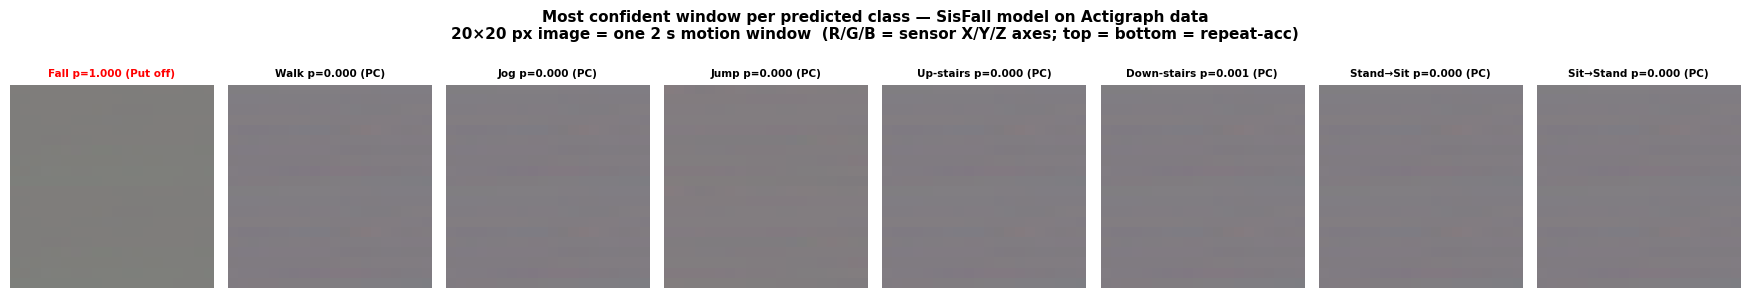

In [12]:
# Best-detected window per predicted class (20\u00d720 RGB image, one per class)
def to_image_acti(window_values):
    """Reshape 1200 flattened sensor values to a displayable 20\u00d720\u00d73 image."""
    img = np.array(window_values, dtype=np.float32).reshape(20, 20, 3)
    return img / 255.0


n_cl = len(FD_CLASS_LIST)
fig, axes = plt.subplots(1, n_cl, figsize=(2.2 * n_cl, 3.2))

for ax, label in zip(axes, FD_CLASS_LIST):
    cls_idx   = FD_CLASS_LIST.index(label)
    best_idx  = int(np.argmax(fd_probs[:, cls_idx]))
    best_prob = fd_probs[best_idx, cls_idx]
    best_task = fd_results.iloc[best_idx]['task']

    img = to_image_acti(fd_windows[best_idx])
    ax.imshow(img)

    name  = FD_CLASS_NAMES[label]
    color = 'red' if label == 0 else 'black'
    ax.set_title(f'{name} p={best_prob:.3f} ({best_task})',
                 fontsize=7.5, color=color, fontweight='bold')
    ax.axis('off')
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'Most confident window per predicted class \u2014 SisFall model on Actigraph data\n'
    '20\u00d720 px image = one 2 s motion window  (R/G/B = sensor X/Y/Z axes; top = bottom = repeat-acc)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 8. Results — per-task summary

In [13]:
if len(fd_results) > 0:
    task_summary = (
        fd_results
        .groupby('task')
        .agg(
            n_windows=('pred_name', 'count'),
            fall_alerts=('pred_label', lambda x: (x == 0).sum()),
            mean_fall_prob=('fall_prob', 'mean'),
            max_fall_prob=('fall_prob', 'max'),
            top_class=('pred_name', lambda x: x.mode()[0]),
        )
        .reset_index()
    )
    task_summary['fall_alert_rate'] = task_summary['fall_alerts'] / task_summary['n_windows']

    task_order = list(dict.fromkeys(classification_tasks_2026_03_29))
    task_summary['_order'] = task_summary['task'].map({t: i for i, t in enumerate(task_order)})
    task_summary = task_summary.sort_values('_order').drop(columns='_order')

    print('=== Per-task AFD-CNN SisFall summary ===')
    print(task_summary.to_string(index=False, float_format='{:.3f}'.format))

=== Per-task AFD-CNN SisFall summary ===
               task  n_windows  fall_alerts  mean_fall_prob  max_fall_prob top_class  fall_alert_rate
             Put on        605          605           1.000          1.000      Fall            1.000
                 RW        233          233           1.000          1.000      Fall            1.000
                 LW        233          233           1.000          1.000      Fall            1.000
                 RA        233          233           1.000          1.000      Fall            1.000
                 LA        233          233           1.000          1.000      Fall            1.000
  In house movement       9078         9078           1.000          1.000      Fall            1.000
             Biking      11266        11266           1.000          1.000      Fall            1.000
Walking fast in gym        353          353           1.000          1.000      Fall            1.000
     Running in gym        473          4

## 9. Visualisation — P(Fall) over time per task

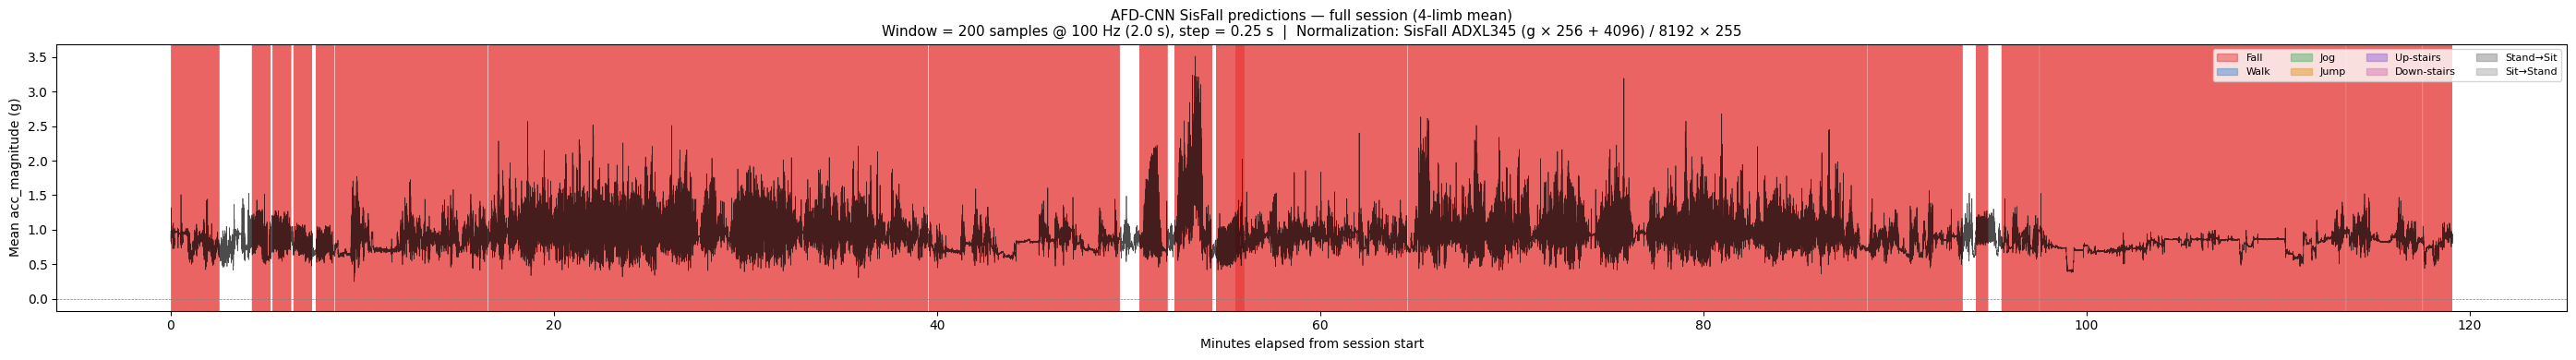

In [14]:
# Full-session timeline: four-limb mean acc_magnitude with AFD-CNN SisFall window shading
if len(fd_results) > 0:
    plot_mean_full = df_mean[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
    plot_mean_full = plot_mean_full[
        (plot_mean_full['Timestamp UTC'] >= SESSION_START) &
        (plot_mean_full['Timestamp UTC'] <= SESSION_END)
    ].copy()
    t_ref_full = plot_mean_full['Timestamp UTC'].iloc[0]
    plot_mean_full['min_elapsed'] = (plot_mean_full['Timestamp UTC'] - t_ref_full).dt.total_seconds() / 60.0

    if len(plot_mean_full) > 80_000:
        plot_mean_full = plot_mean_full.iloc[::max(1, len(plot_mean_full) // 80_000)].copy()

    fig, ax = plt.subplots(figsize=(28, 4))
    ax.plot(plot_mean_full['min_elapsed'], plot_mean_full['acc_magnitude'], color='black', lw=0.5, alpha=0.7)

    for _, row in fd_results.iterrows():
        s = (row['start_dt'] - t_ref_full).total_seconds() / 60.0
        e = (row['end_dt']   - t_ref_full).total_seconds() / 60.0
        ax.axvspan(s, e, color=FD_COLORS.get(row['pred_label'], '#cccccc'), alpha=0.18, linewidth=0)

    ax.axhline(0, color='0.5', ls='--', lw=0.5)
    ax.set_xlabel('Minutes elapsed from session start')
    ax.set_ylabel('Mean acc_magnitude (g)')
    ax.set_title(
        f'AFD-CNN SisFall predictions \u2014 full session (4-limb mean)\n'
        f'Window = {FD_WIN_LEN} samples @ {FD_FS_TRAIN} Hz ({FD_WIN_LEN/FD_FS_TRAIN:.1f} s), '
        f'step = {FD_STEP/FD_FS_TRAIN:.2f} s  |  '
        f'Normalization: SisFall ADXL345 (g \u00d7 256 + 4096) / 8192 \u00d7 255',
        fontsize=11,
    )
    legend_patches = [
        mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
        for l in FD_CLASS_LIST
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc='upper right', ncol=4, framealpha=0.8)
    plt.tight_layout()
    plt.show()

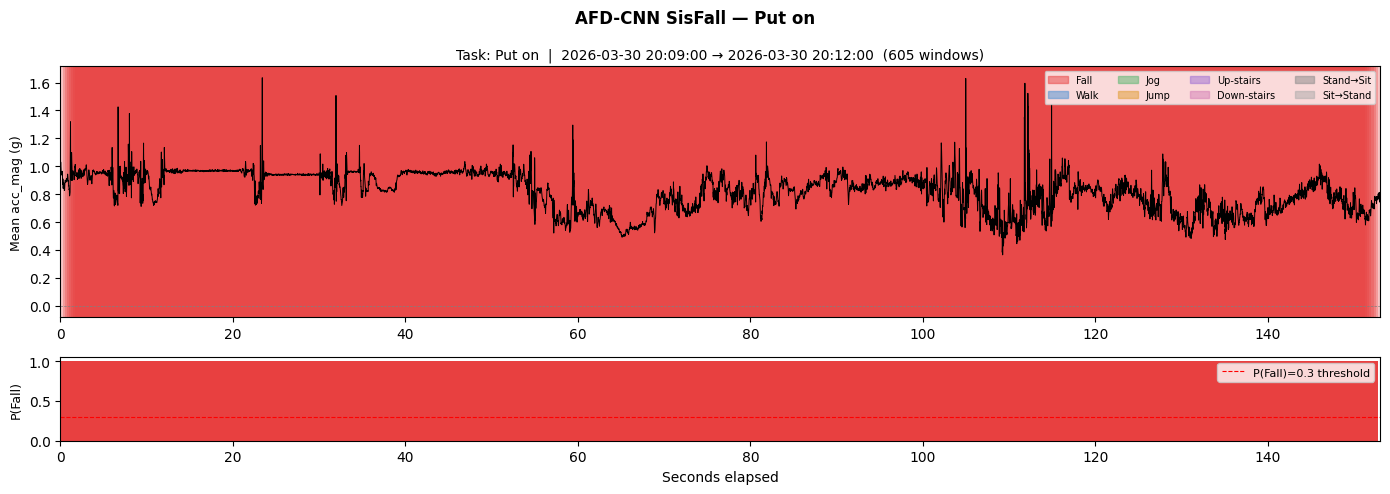

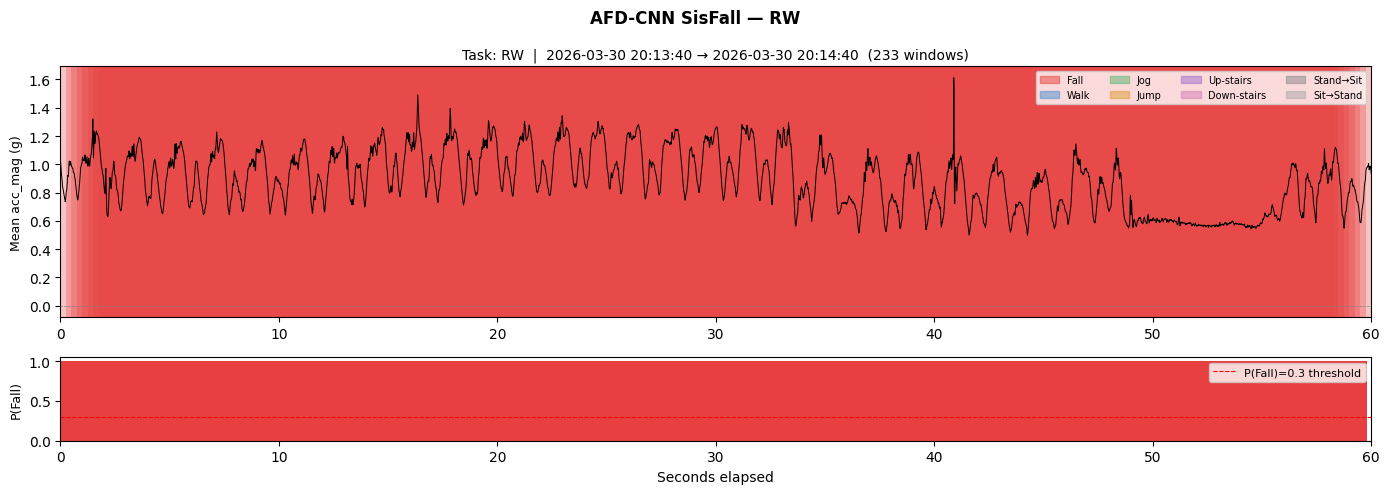

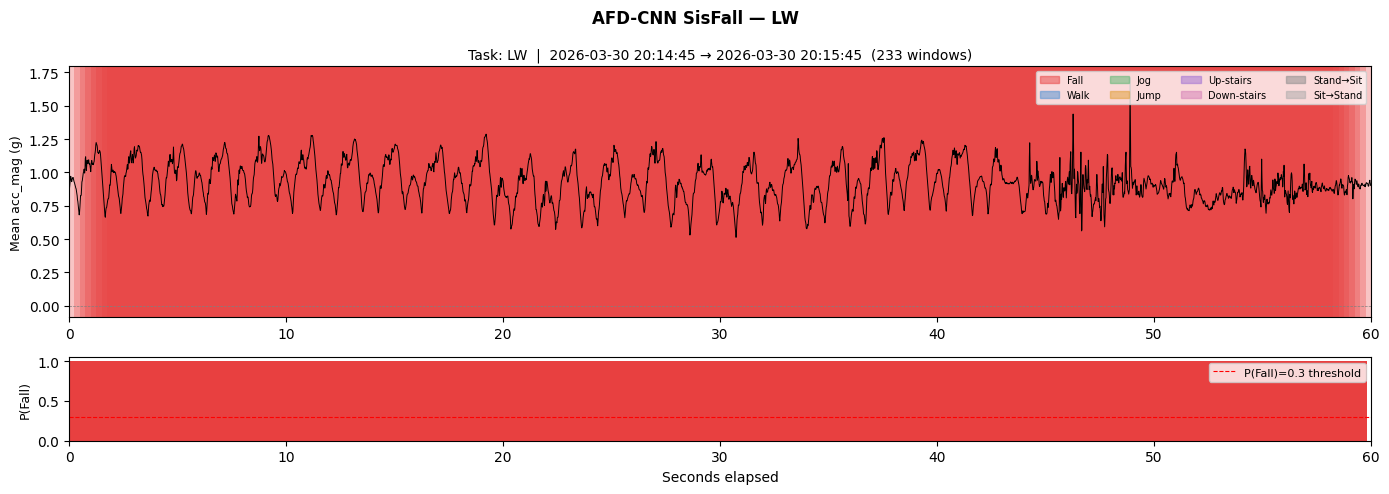

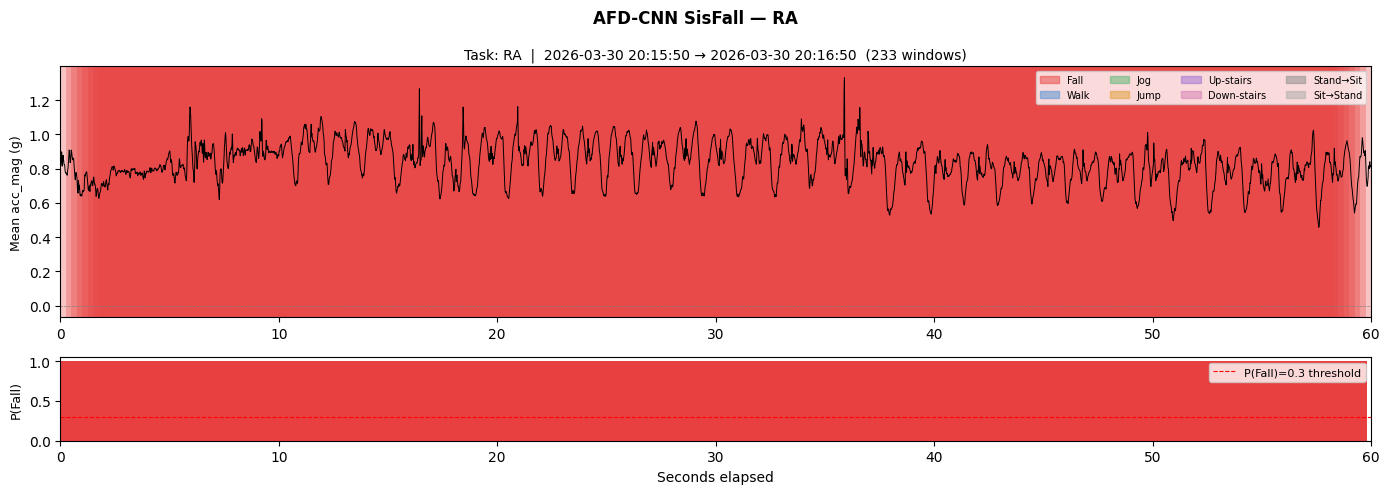

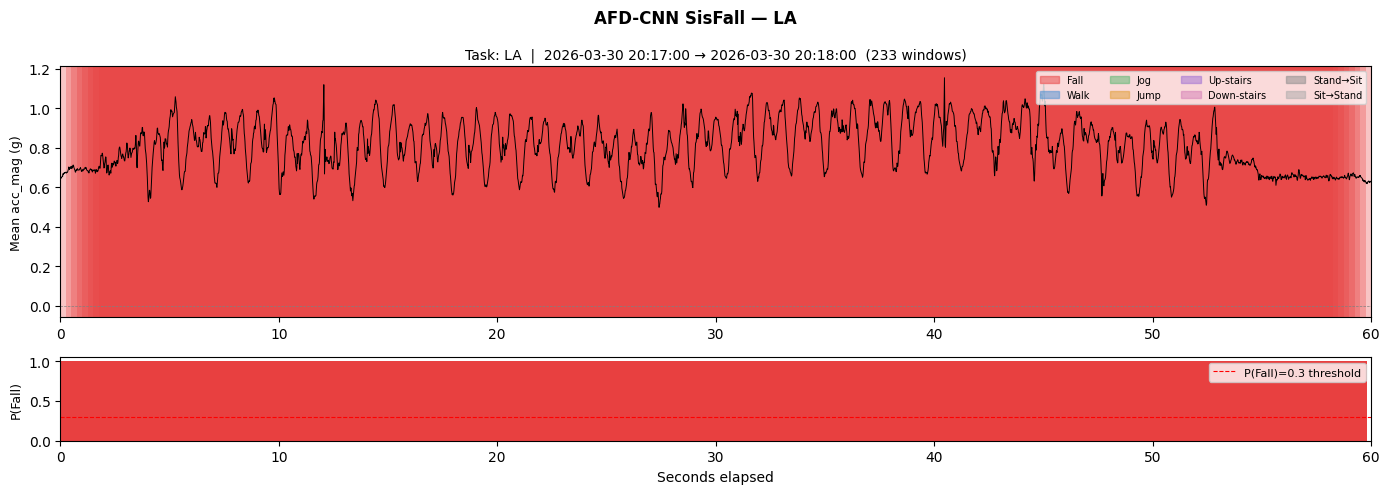

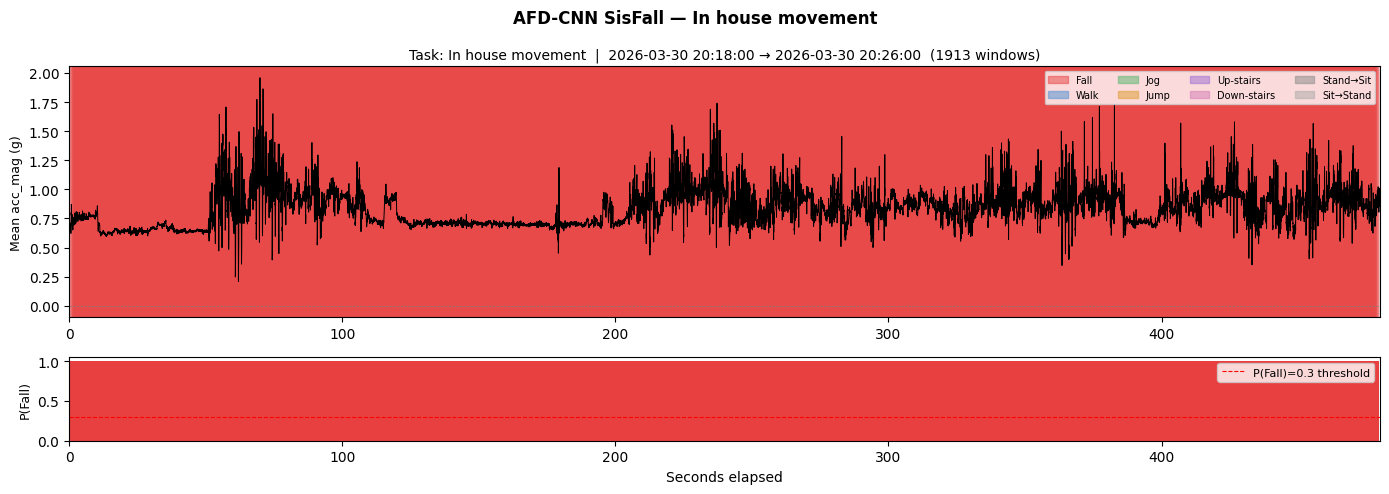

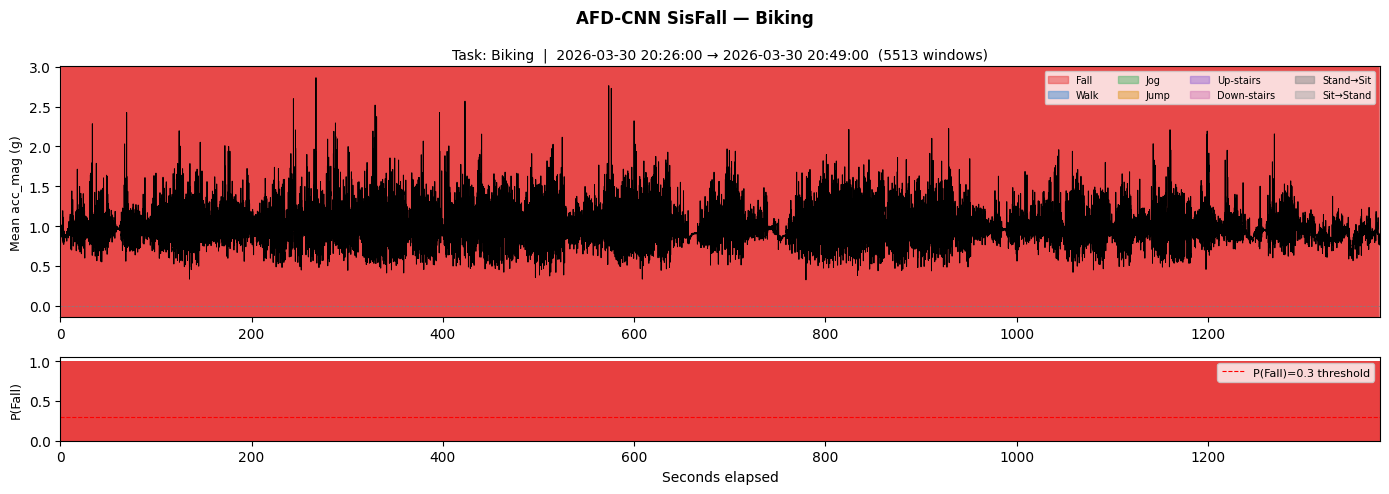

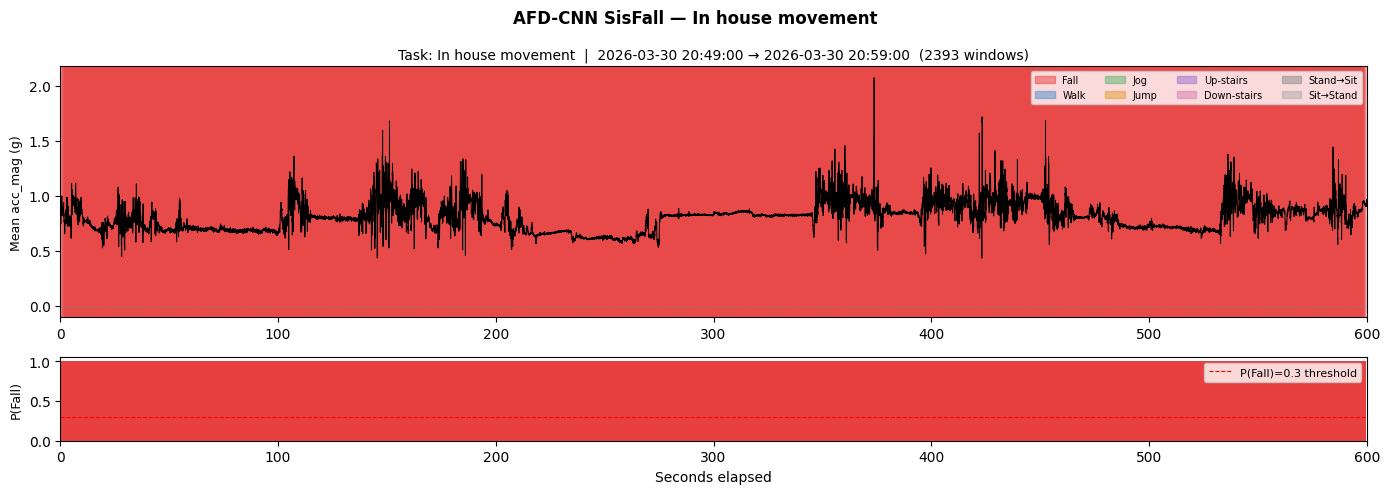

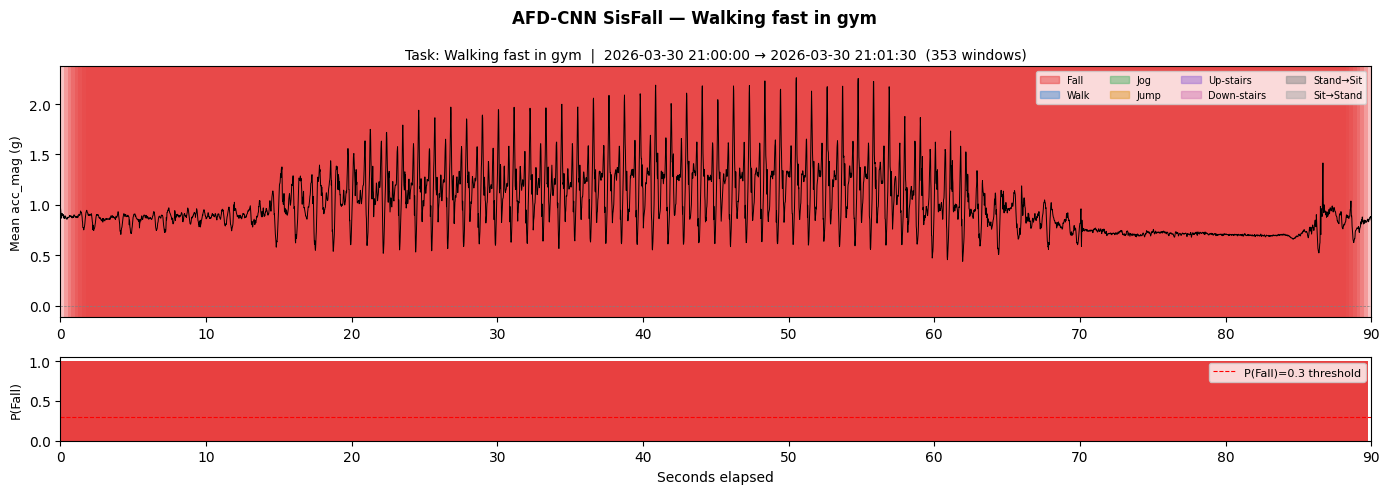

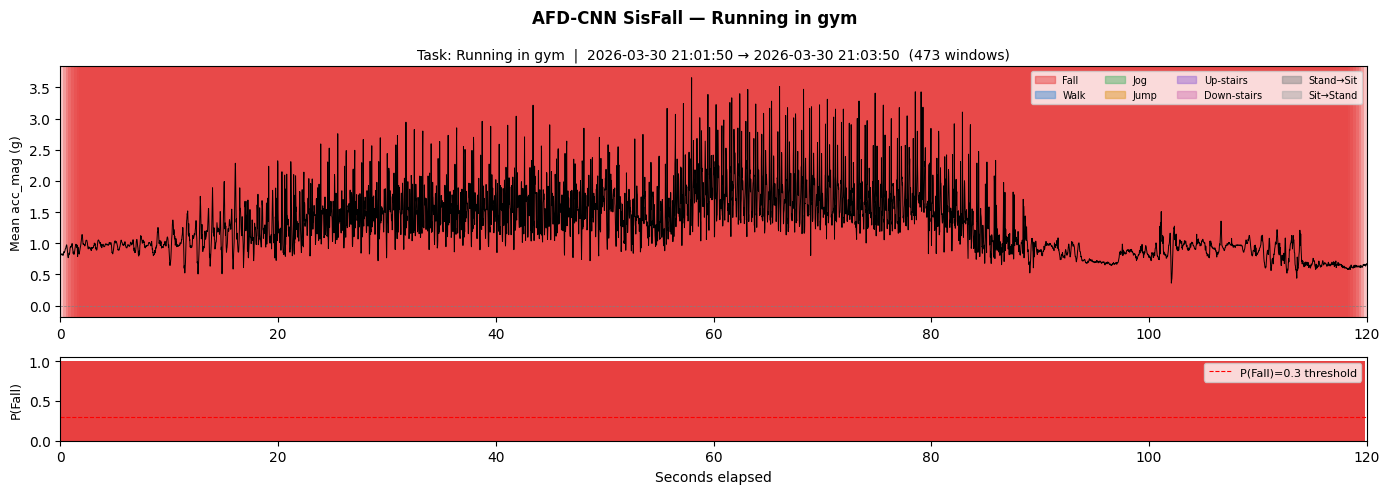

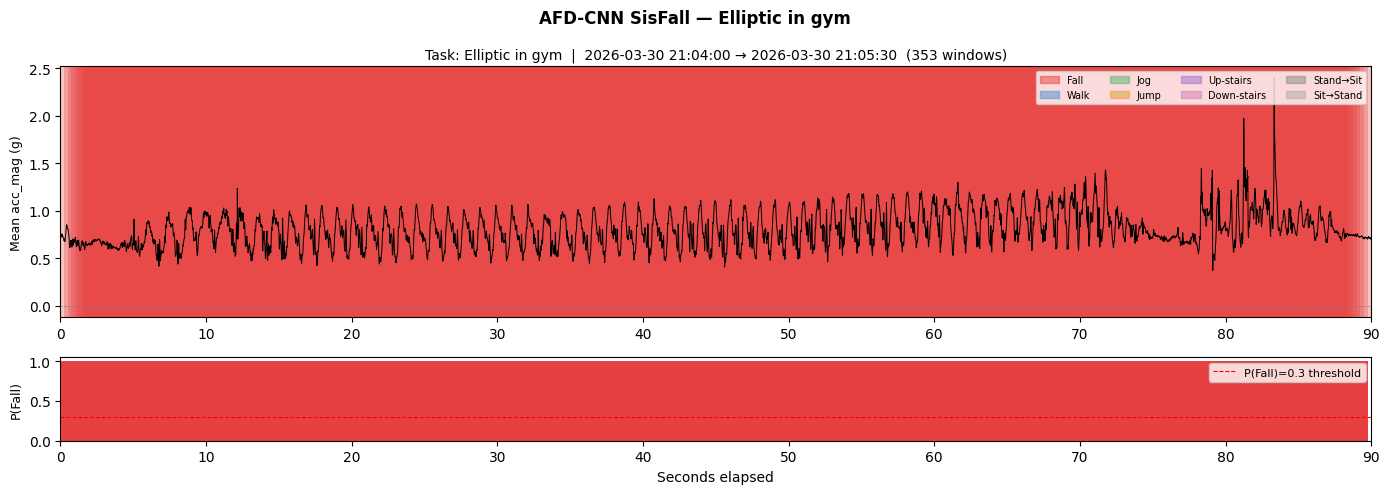

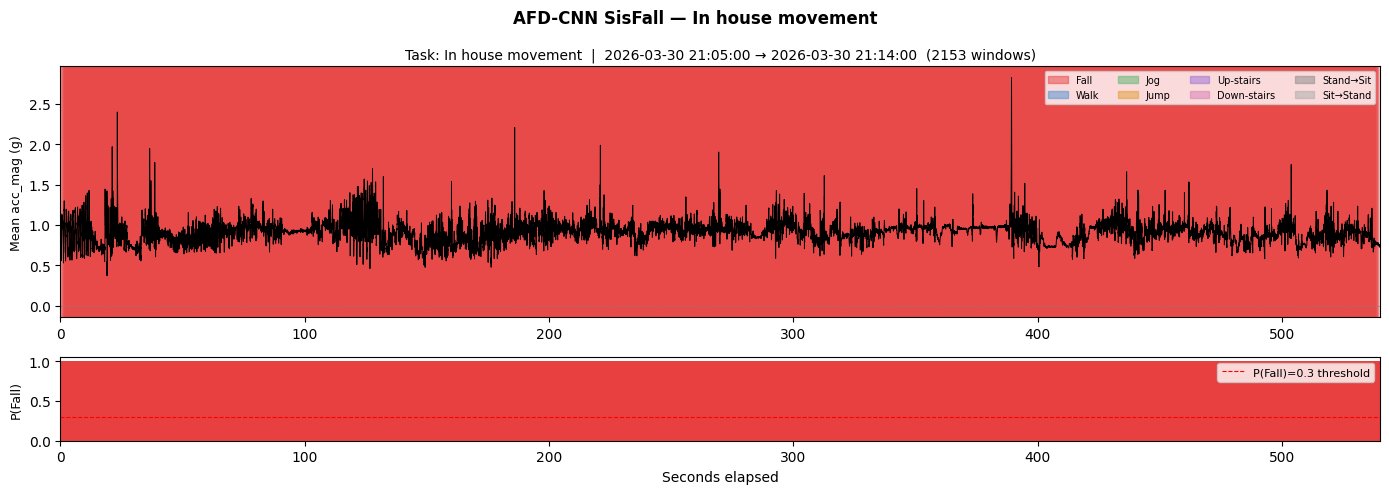

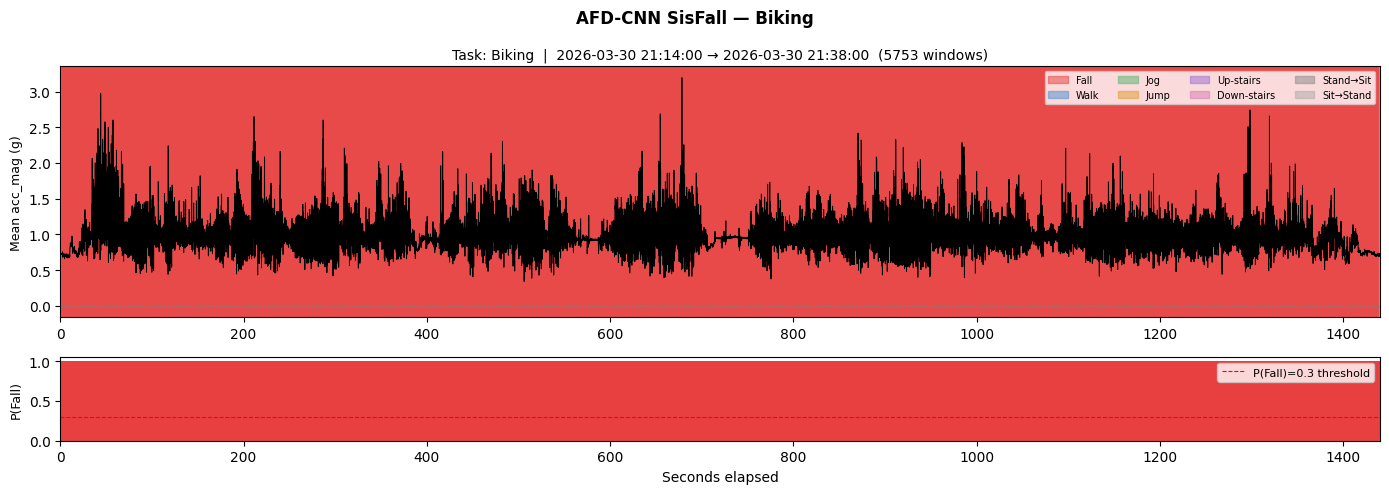

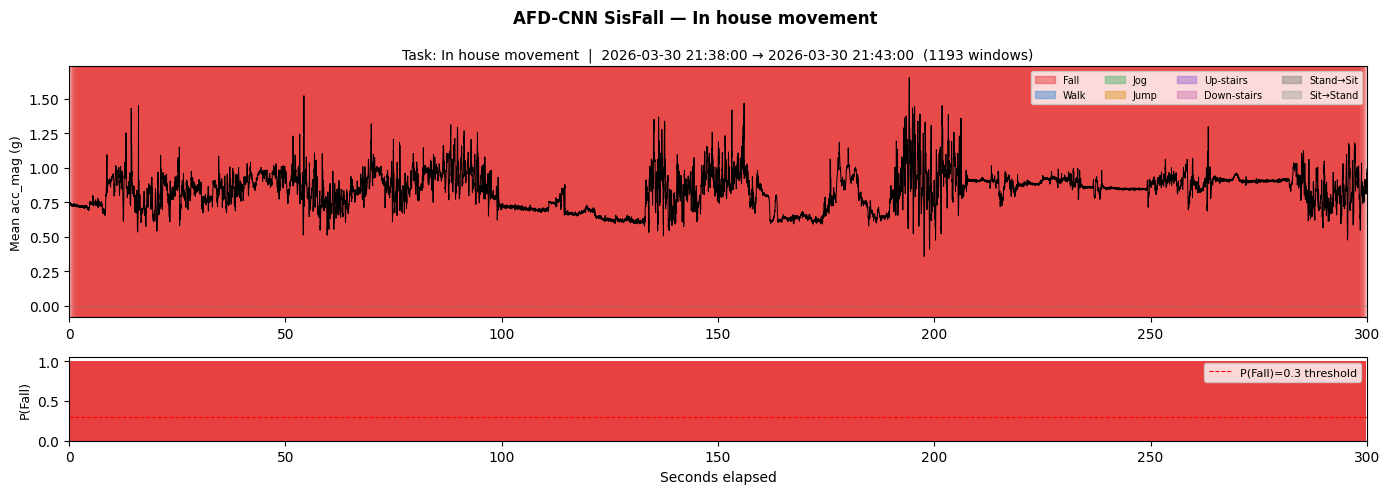

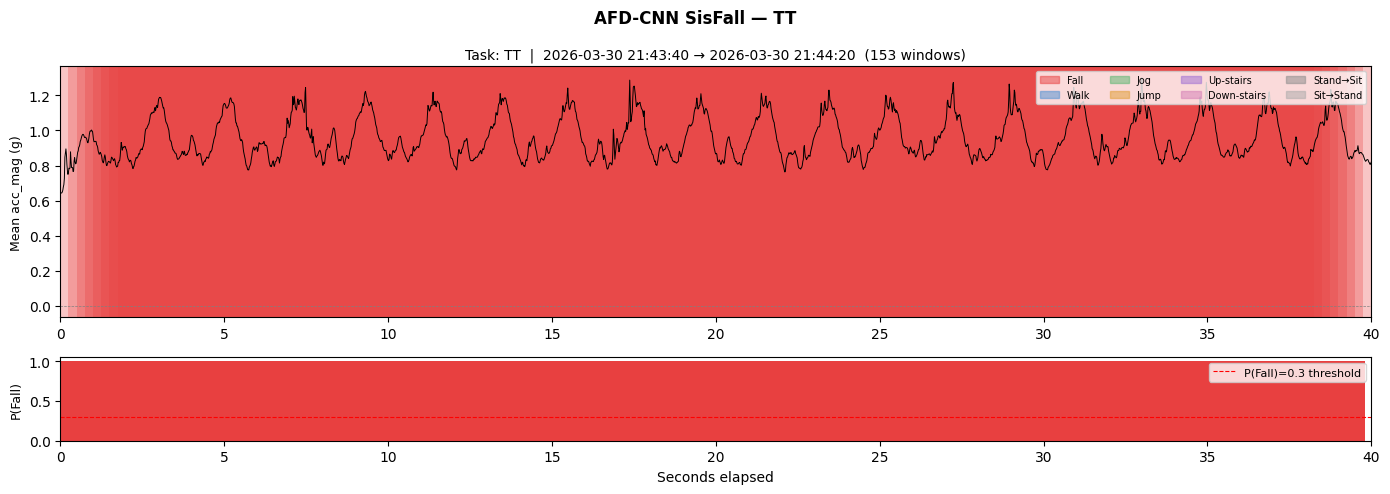

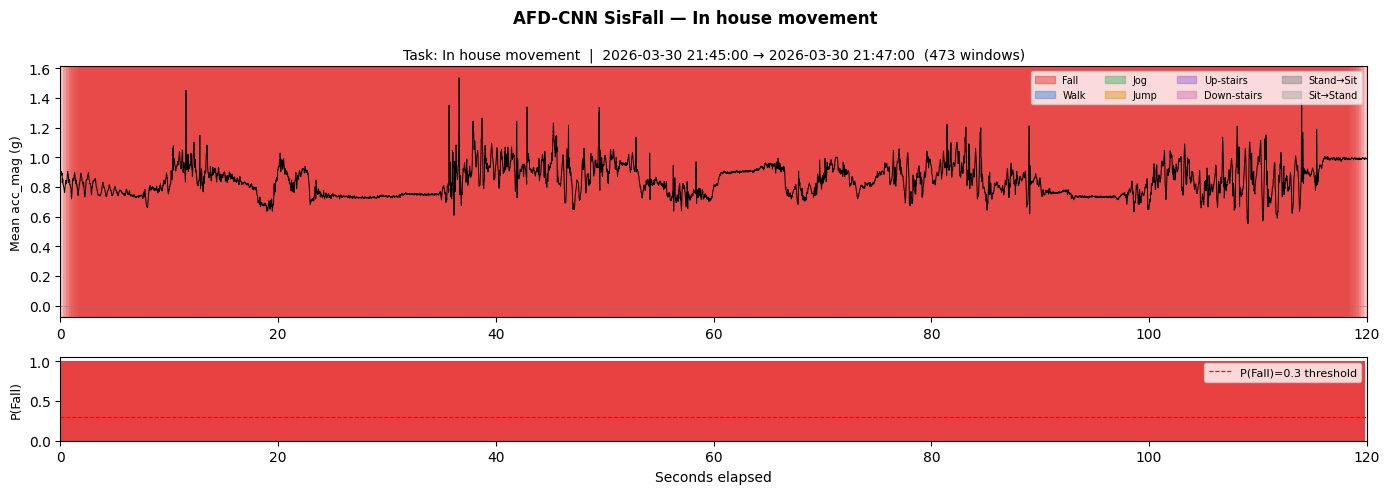

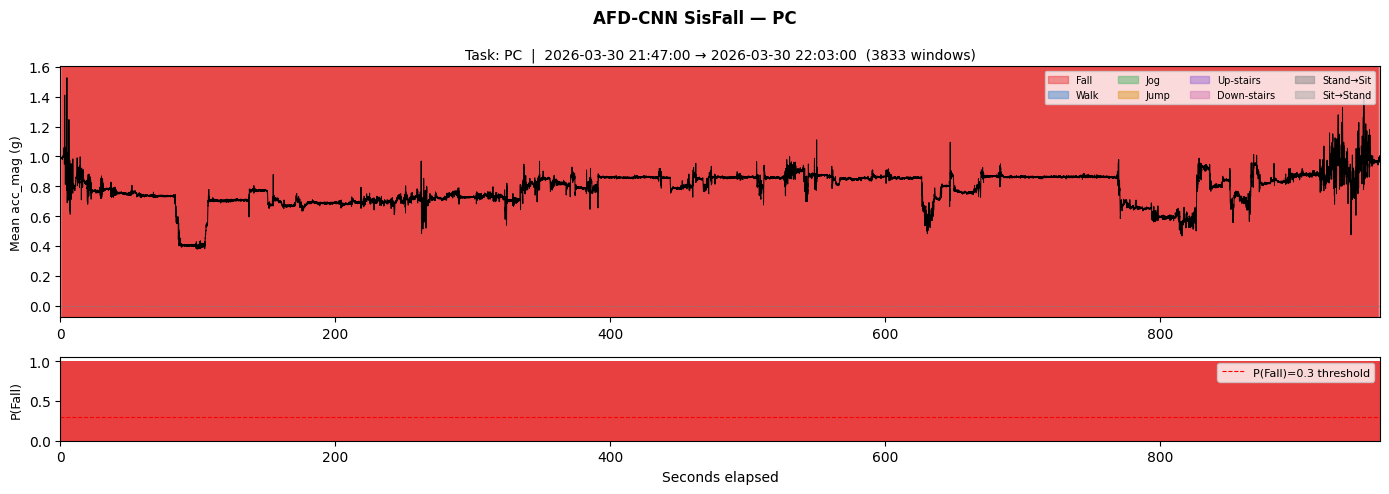

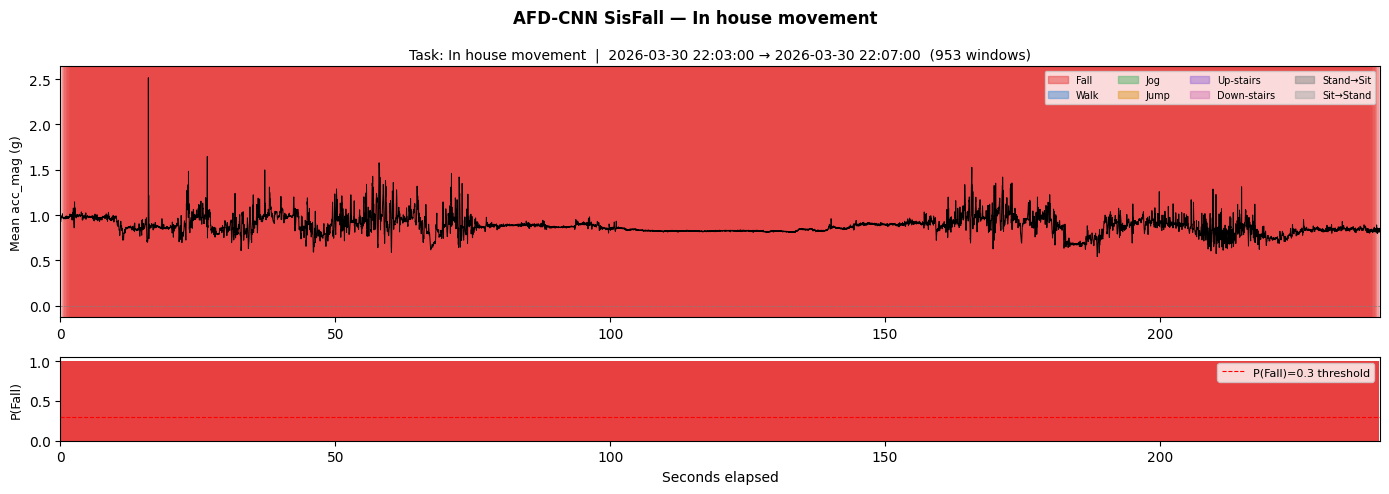

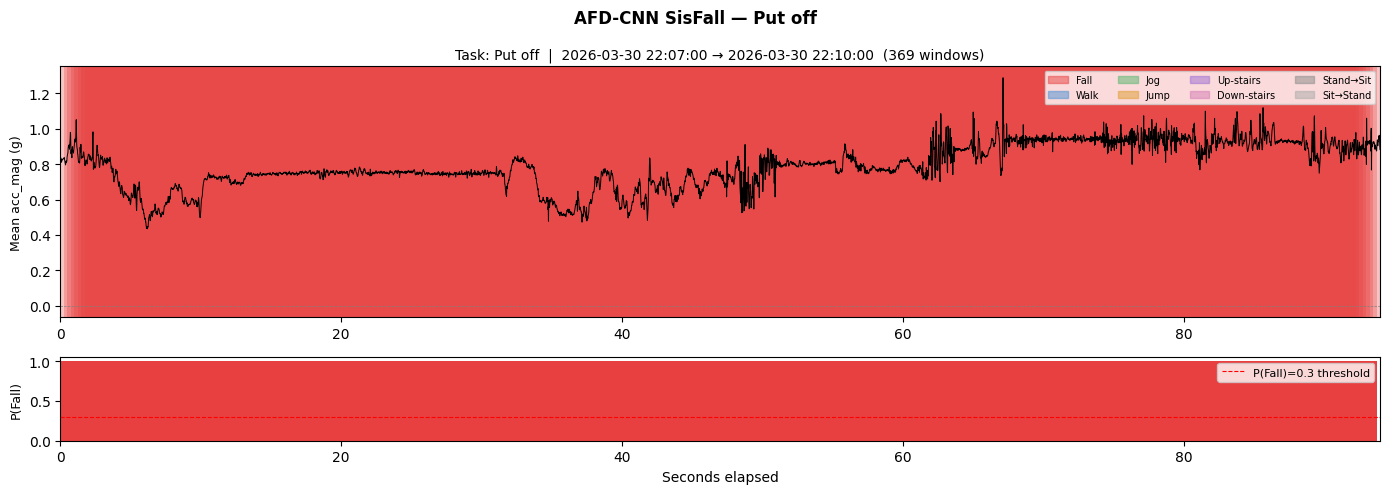

In [15]:
# Per-task zoom: one figure per tagged window showing four-limb mean signal + AFD-CNN SisFall predictions
if len(fd_results) > 0:
    for (win_str, task) in zip(classification_windows_2026_03_29, classification_tasks_2026_03_29):
        t0_z, tf_z = resolve_time_window(win_str)

        task_wins = fd_results[
            (fd_results['task'] == task) &
            (fd_results['start_dt'] >= t0_z) &
            (fd_results['end_dt']   <= tf_z)
        ].copy()
        if task_wins.empty:
            continue

        seg_mean_z = df_mean[
            (df_mean['Timestamp UTC'] >= t0_z) &
            (df_mean['Timestamp UTC'] <= tf_z)
        ][['Timestamp UTC', 'acc_magnitude']].dropna().copy()
        if seg_mean_z.empty:
            continue

        t_ref_z = seg_mean_z['Timestamp UTC'].iloc[0]
        seg_mean_z['sec_elapsed'] = (seg_mean_z['Timestamp UTC'] - t_ref_z).dt.total_seconds()
        if len(seg_mean_z) > 20_000:
            seg_mean_z = seg_mean_z.iloc[::max(1, len(seg_mean_z) // 20_000)].copy()

        fig, (ax_sig, ax_fall) = plt.subplots(
            2, 1, figsize=(14, 5),
            gridspec_kw={'height_ratios': [3, 1]},
        )

        # \u2500\u2500 Signal panel \u2500\u2500
        ax_sig.plot(seg_mean_z['sec_elapsed'], seg_mean_z['acc_magnitude'], color='black', lw=0.7)
        for _, row in task_wins.iterrows():
            s = (row['start_dt'] - t_ref_z).total_seconds()
            e = (row['end_dt']   - t_ref_z).total_seconds()
            ax_sig.axvspan(s, e,
                           color=FD_COLORS.get(row['pred_label'], '#cccccc'),
                           alpha=0.30, linewidth=0)
        ax_sig.axhline(0, color='0.5', ls='--', lw=0.5)
        ax_sig.set_ylabel('Mean acc_mag (g)', fontsize=9)
        ax_sig.set_title(
            f'Task: {task}  |  {win_str[0]} \u2192 {win_str[1]}  '
            f'({len(task_wins)} windows)',
            fontsize=10,
        )
        ax_sig.legend(
            handles=[mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
                     for l in FD_CLASS_LIST],
            fontsize=7, loc='upper right', ncol=4, framealpha=0.8,
        )

        # \u2500\u2500 P(Fall) bar panel \u2500\u2500
        x_sec = [(row['start_dt'] - t_ref_z).total_seconds() for _, row in task_wins.iterrows()]
        colors_bar = ['#e84040' if p >= 0.3 else '#4a8fd4' for p in task_wins['fall_prob']]
        ax_fall.bar(x_sec, task_wins['fall_prob'], width=FD_WIN_LEN / FD_FS_TRAIN * 0.9,
                    color=colors_bar, edgecolor='none', align='edge')
        ax_fall.axhline(0.3, color='red', ls='--', lw=0.8, label='P(Fall)=0.3 threshold')
        ax_fall.set_ylim(0, 1.05)
        ax_fall.set_ylabel('P(Fall)', fontsize=9)
        ax_fall.set_xlabel('Seconds elapsed')
        ax_fall.legend(fontsize=8, loc='upper right')

        x_min = seg_mean_z['sec_elapsed'].iloc[0]
        x_max = seg_mean_z['sec_elapsed'].iloc[-1]
        ax_sig.set_xlim(x_min, x_max)
        ax_fall.set_xlim(x_min, x_max)

        fig.suptitle(f'AFD-CNN SisFall \u2014 {task}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

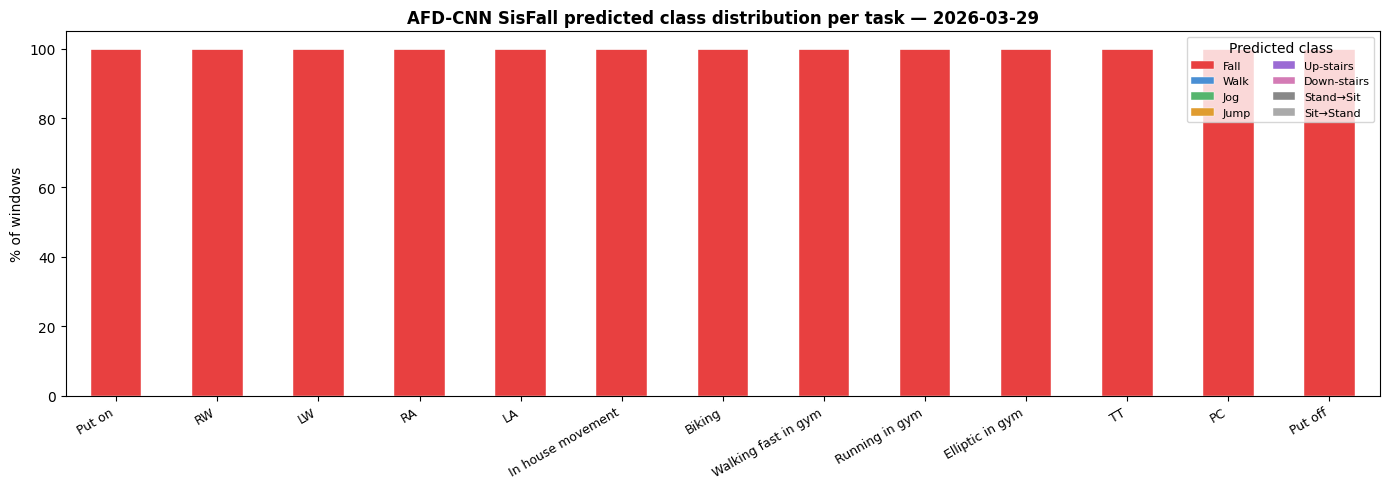


=== Predicted class distribution per task (window counts) ===
pred_name             Fall  Walk  Jog  Jump  Up-stairs  Down-stairs  Stand→Sit  Sit→Stand
task                                                                                     
Put on                 605     0    0     0          0            0          0          0
RW                     233     0    0     0          0            0          0          0
LW                     233     0    0     0          0            0          0          0
RA                     233     0    0     0          0            0          0          0
LA                     233     0    0     0          0            0          0          0
In house movement     9078     0    0     0          0            0          0          0
Biking               11266     0    0     0          0            0          0          0
Walking fast in gym    353     0    0     0          0            0          0          0
Running in gym         473     0    0

In [16]:
# Stacked bar: predicted class distribution per task
if len(fd_results) > 0:
    _class_order = [FD_CLASS_NAMES[l] for l in FD_CLASS_LIST]
    _counts = (
        fd_results
        .groupby(['task', 'pred_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=_class_order, fill_value=0)
    )
    task_order = list(dict.fromkeys(classification_tasks_2026_03_29))
    _counts = _counts.reindex([t for t in task_order if t in _counts.index])

    _pct = _counts.div(_counts.sum(axis=1), axis=0) * 100
    _class_colors = [FD_COLORS[l] for l in FD_CLASS_LIST]

    fig, ax = plt.subplots(figsize=(14, 5))
    _pct.plot(kind='bar', stacked=True, ax=ax, color=_class_colors,
              edgecolor='white', linewidth=0.3)
    ax.set_ylabel('% of windows', fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(_pct.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 105)
    ax.legend(title='Predicted class', fontsize=8, loc='upper right', ncol=2)
    ax.set_title('AFD-CNN SisFall predicted class distribution per task \u2014 2026-03-29',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== Predicted class distribution per task (window counts) ===')
    print(_counts.to_string())

## 10. SKDH walking bouts vs AFD-CNN SisFall predictions

In [17]:
# Cross-reference: for each SKDH-detected gait bout, show AFD-CNN SisFall window predictions
if n_bouts > 0 and len(fd_results) > 0:
    gait_starts_utc = pd.to_datetime(skdh_result_session['Gait Bout Start'], unit='s', utc=True)
    gait_stops_utc  = pd.to_datetime(skdh_result_session['Gait Bout Stop'],  unit='s', utc=True)

    print('=== AFD-CNN SisFall predictions inside SKDH gait bouts ===')
    for i, (gs, ge) in enumerate(zip(gait_starts_utc, gait_stops_utc)):
        dur = (ge - gs).total_seconds()

        in_bout = fd_results[
            (fd_results['start_dt'] >= gs) & (fd_results['start_dt'] <= ge)
        ]
        if in_bout.empty:
            print(f'  Bout {i+1} ({dur:.0f} s): no AFD-CNN windows matched')
            continue

        n_fall_bout = (in_bout['pred_label'] == 0).sum()
        top_task    = in_bout['task'].mode()[0] if 'task' in in_bout.columns else '?'
        print(f'  Bout {i+1} ({dur:.0f} s | {gs.strftime("%H:%M:%S")}\u2013{ge.strftime("%H:%M:%S")}): '
              f'{len(in_bout)} windows  |  '
              f'Fall alerts: {n_fall_bout}  |  '
              f'Top class: {in_bout["pred_name"].mode()[0]}  |  '
              f'Task tag: {top_task}')
else:
    print('No SKDH gait bouts detected or no AFD-CNN results available.')

=== AFD-CNN SisFall predictions inside SKDH gait bouts ===
  Bout 1 (3 s): no AFD-CNN windows matched
  Bout 2 (6 s | 20:18:57–20:19:03): 25 windows  |  Fall alerts: 25  |  Top class: Fall  |  Task tag: In house movement
  Bout 3 (3 s | 20:21:42–20:21:45): 13 windows  |  Fall alerts: 13  |  Top class: Fall  |  Task tag: In house movement
  Bout 4 (6 s | 20:22:03–20:22:09): 25 windows  |  Fall alerts: 25  |  Top class: Fall  |  Task tag: In house movement
  Bout 5 (3 s | 20:22:24–20:22:27): 13 windows  |  Fall alerts: 13  |  Top class: Fall  |  Task tag: In house movement
  Bout 6 (3 s | 20:22:51–20:22:54): 13 windows  |  Fall alerts: 13  |  Top class: Fall  |  Task tag: In house movement
  Bout 7 (3 s | 20:26:00–20:26:03): 13 windows  |  Fall alerts: 13  |  Top class: Fall  |  Task tag: Biking
  Bout 8 (3 s | 20:34:15–20:34:18): 13 windows  |  Fall alerts: 13  |  Top class: Fall  |  Task tag: Biking
  Bout 9 (3 s | 20:35:30–20:35:33): 13 windows  |  Fall alerts: 13  |  Top class: Fall 

In [18]:
# Close TF session
fd_sess.close()
print('TF session closed.')

TF session closed.
